##  8.0 stepup page 

In [2]:
# ===================== 08.0 Setup =====================
import sys, json
from pathlib import Path
import pandas as pd

# --- project root (the notebook runs from notebooks/) ---
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.paths import SECTIONS, CHUNKS

# --- where evaluation files and models live ---
EVAL_DIR   = ROOT / "data" / "eval"
QUESTIONS  = EVAL_DIR / "questions.csv"
MODELS_DIR = ROOT / "models"                 # models stay inside the project, not in Temp
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# --- settings used by every stage ---
TOP_K  = 10     # each search returns this many chunks
SEND_K = 5      # chunks we would send to the LLM → hit@5, precision@5

# --- load the two inputs as DataFrames ---
# dtype=False keeps values exactly as saved (so "8.10" stays "8.10", not 8.1)
read = lambda p: pd.read_json(p, lines=True, dtype=False, convert_dates=False)
sections_df = read(SECTIONS)
chunks_df   = read(CHUNKS)

# --- the unit we score on: a section id ("S017"), or "L05" for letter 5 ---
def unit_of(row):
    return f"L{int(row['letter_no']):02d}" if pd.notna(row["letter_no"]) else row["section_id"]
chunks_df["unit"] = chunks_df.apply(unit_of, axis=1)

# --- readable name for every unit (used when showing results) ---
UNIT_NAME = dict(zip(sections_df["section_id"], sections_df["label"]))
letters = chunks_df[chunks_df["unit"].str.startswith("L")]
UNIT_NAME.update(dict(zip(letters["unit"], letters["path"].str[-1])))

# --- quick checks on the inputs ---
assert chunks_df["chunk_id"].is_unique, "duplicate chunk_id"
assert chunks_df["unit"].notna().all(), "a chunk without section or letter"
unknown = set(chunks_df.loc[~chunks_df["unit"].str.startswith("L"), "unit"]) - set(sections_df["section_id"])
assert not unknown, f"chunks point to unknown sections: {unknown}"

print(f"sections: {len(sections_df)} | chunks: {len(chunks_df)} | letters: {letters['unit'].nunique()}")
print(chunks_df["doc_type"].value_counts().to_string())
chunks_df[["chunk_id", "doc_type", "unit", "n_chars"]].head()

sections: 106 | chunks: 466 | letters: 21
doc_type
section        314
table           82
letter          68
letter_stub      2


,chunk_id,doc_type,unit,n_chars
0,T15-1-01,table,S001,702
1,T16-1-01,table,S001,596
2,S002-01,section,S002,554
3,S002-02,section,S002,1034
4,S002-03,section,S002,847


## 08.1 Stage 1: read the questions

In [3]:
import re
# ===================== 08.1 Stage 1: read the questions =====================
REQUIRED = ["qid", "question", "pdf_page"]
OPTIONAL = ["phrase", "type"]
TYPES    = {"keyword", "paraphrase", "acronym", "table", "letter", "unreadable", "untyped"}
PAGE_RE  = re.compile(r"^\d{1,3}(\s*-\s*\d{1,3})?$")          # 43  or  43-44

for enc in ("utf-8-sig", "utf-8", "cp1252", "latin-1"):
    try:
        questions_df = pd.read_csv(
            QUESTIONS,
            dtype=str,
            keep_default_na=False,
            encoding=enc,
            engine="python",
            on_bad_lines="skip",
        )
        break
    except UnicodeDecodeError:
        continue
else:
    with open(QUESTIONS, "r", encoding="utf-8", errors="replace", newline="") as f:
        questions_df = pd.read_csv(f, dtype=str, keep_default_na=False, engine="python", on_bad_lines="skip")
questions_df.columns = questions_df.columns.str.strip()

missing_cols = [c for c in REQUIRED if c not in questions_df.columns]
assert not missing_cols, f"questions file is missing columns: {missing_cols}"
for c in OPTIONAL:
    if c not in questions_df.columns:
        questions_df[c] = ""

questions_df = questions_df.apply(lambda col: col.str.strip())
questions_df["type"] = questions_df["type"].str.lower().replace("", "untyped")

DUPLICATE_QIDS = set(questions_df.loc[questions_df["qid"].duplicated(), "qid"])

def row_problems(r):
    p = []
    if not r["question"]:                 p.append("empty question")
    if not PAGE_RE.match(r["pdf_page"]):  p.append(f"pdf_page '{r['pdf_page']}' is not like 43 or 43-44")
    if r["type"] not in TYPES:            p.append(f"unknown type '{r['type']}'")
    if r["qid"] in DUPLICATE_QIDS:        p.append("duplicate qid")
    return "; ".join(p)

questions_df["problem"] = questions_df.apply(row_problems, axis=1)
ok = questions_df["problem"] == ""
print(f"{len(questions_df)} questions | ok: {ok.sum()} | with a problem: {(~ok).sum()}")
print(questions_df["type"].value_counts().to_string())
questions_df[~ok]

200 questions | ok: 200 | with a problem: 0
type
keyword       93
paraphrase    75
acronym       14
letter        14
table          2
unreadable     2


,qid,question,pdf_page,phrase,type,problem


## 08.2 Stage 2: answer key → units

In [4]:
# ===================== 08.2 Stage 2: answer key = PDF pages =====================
N_PAGES   = 174
flat      = lambda t: " ".join(re.findall(r"\w+", str(t).lower()))   # words only
FLAT_TEXT = chunks_df["text"].map(flat)
PAGES_OF  = chunks_df["pdf_pages"].map(set)                        # pages each chunk covers

def page_set(text):
    """'43' → {43};  '43-44' → {43, 44}"""
    a, _, b = text.replace(" ", "").partition("-")
    a, b = int(a), int(b or a)
    return set(range(min(a, b), max(a, b) + 1))

def answer_key(r):
    if r["problem"]:                                   # stage 1 already rejected it
        return pd.Series({"targets": [], "key_problem": ""})
    pages, problems = page_set(r["pdf_page"]), []
    on_page = PAGES_OF.map(lambda s: bool(s & pages))  # chunks that touch these pages
    if not all(1 <= p <= N_PAGES for p in pages):
        problems.append(f"page outside 1-{N_PAGES}")
    elif not on_page.any():
        problems.append("no chunk on this page (blank, contents or cover page?)")
    elif r["phrase"] and not FLAT_TEXT[on_page].str.contains(flat(r["phrase"]), regex=False).any():
        problems.append("phrase not found on that page")
    return pd.Series({"targets": sorted(pages), "key_problem": "; ".join(problems)})

key_df = questions_df.apply(answer_key, axis=1)
questions_df = questions_df.drop(columns=key_df.columns, errors="ignore").join(key_df)
questions_df["target_names"] = questions_df["targets"].map(
    lambda ps: f"PDF p.{ps[0]}" + (f"-{ps[-1]}" if len(ps) > 1 else "") if ps else "")

bad = (questions_df["problem"] != "") | (questions_df["key_problem"] != "")
checked_df  = questions_df[~bad].reset_index(drop=True)
rejected_df = questions_df[bad].reset_index(drop=True)

print(f"ready: {len(checked_df)} | rejected: {len(rejected_df)}")
display(rejected_df[["qid", "pdf_page", "phrase", "problem", "key_problem"]])
checked_df[["qid", "type", "pdf_page", "target_names", "question"]]

ready: 185 | rejected: 15


,qid,pdf_page,phrase,problem,key_problem
0,Q63,41,No separate TMIS should be run,,phrase not found on that page
1,Q87,47,Equal pay for equal work,,phrase not found on that page
2,Q88,47,undertake a market analysis,,phrase not found on that page
3,Q89,47,parity in salary across various pools,,phrase not found on that page
4,Q90,48,requisite qualification can apply for higher l...,,phrase not found on that page
5,Q91,48,weightage of marks (up to 25%),,phrase not found on that page
6,Q92,48,well-versed with the nature of work,,phrase not found on that page
7,Q93,48,Career advancement tracks for all cadres,,phrase not found on that page
8,Q94,48,online as well as offline facility,,phrase not found on that page
9,Q95,48,utmost confidentiality and sensitivity,,phrase not found on that page


,qid,type,pdf_page,target_names,question
0,Q01,paraphrase,31,PDF p.31,We are planning a new NHM recruitment drive. W...
1,Q02,paraphrase,32,PDF p.32,Our district has been asked to conduct recruit...
2,Q03,keyword,32,PDF p.32,How many members can be included in an NHM rec...
3,Q04,paraphrase,32,PDF p.32,Can someone from the programme division whose ...
4,Q05,paraphrase,32,PDF p.32,How frequently should we review our vacancies ...
...,...,...,...,...,...
180,Q196,keyword,163,PDF p.163,How long is pre-service training for health wo...
181,Q197,acronym,165,PDF p.165,How much did Kangaroo Mother Care initiation i...
182,Q198,paraphrase,167,PDF p.167,What incentive did specialist mentors get for ...
183,Q199,keyword,168,PDF p.168,For what term are contractual staff engaged in...


In [5]:
# ===================== 08.3 Stage 3a: BM25 search =====================
import re
import numpy as np
from rank_bm25 import BM25Okapi
import snowballstemmer

# --- same tokenizer as 07 (version D): lowercase, drop common words, stem ---
STOP = set("""a an the of to in on for and or is are was were be been by with as at from that this these those it its
what which who whom how why when where does do did should shall can could will would may might must about into than
there their they them his her he she we our you your i my me not no any all""".split())
_stem = snowballstemmer.stemmer("english").stemWord

def tokenize(text):
    words = re.findall(r"[a-z0-9]+", text.lower())
    return [_stem(w) for w in words if w not in STOP]

# --- the index: built once from every chunk's path + text ---
bm25 = BM25Okapi([tokenize(t) or ["_empty_"] for t in chunks_df["embed_text"]])

def search_bm25(question, k=TOP_K):
    """question → [(row number in chunks_df, score), ...] best first"""
    scores = bm25.get_scores(tokenize(question))
    top = np.argsort(-scores, kind="stable")[:k]
    return [(i, float(scores[i])) for i in top]

def run_search(name, search, questions):
    rows = []
    for q in questions.itertuples():
        targets = set(q.targets)                                   # expected PDF pages
        for rank, (i, score) in enumerate(search(q.question), 1):
            pages = chunks_df.at[i, "pdf_pages"]
            rows.append({"retriever": name, "qid": q.qid, "rank": rank,
                         "chunk_id": chunks_df.at[i, "chunk_id"], "unit": chunks_df.at[i, "unit"],
                         "pages": pages, "score": round(score, 4),
                         "correct": bool(set(pages) & targets)})   # right page = correct
    return pd.DataFrame(rows)

RESULTS = {}                                       # one DataFrame per searcher; re-running replaces it
RESULTS["bm25"] = run_search("bm25", search_bm25, checked_df)
results_df = pd.concat(RESULTS.values(), ignore_index=True)

# --- checks + a first look ---
per_q = results_df.groupby(["retriever", "qid"]).size()
assert (per_q == TOP_K).all(), "a question did not get TOP_K results"
print(f"{len(results_df)} result rows = {results_df['qid'].nunique()} questions × {TOP_K} ranks × {results_df['retriever'].nunique()} retriever(s)")

top5 = results_df[(results_df["rank"] <= SEND_K) & results_df["correct"]]
print("quick check, hit@5:", round(top5["qid"].nunique() / checked_df["qid"].nunique(), 3))

first = checked_df["qid"].iloc[0]
results_df[results_df["qid"] == first].assign(name=lambda d: d["unit"].map(UNIT_NAME).str[:45])

1850 result rows = 185 questions × 10 ranks × 1 retriever(s)
quick check, hit@5: 0.951


,retriever,qid,rank,chunk_id,unit,pages,score,correct,name
0,bm25,Q01,1,S020-01,S020,[31],12.5280,True,Chapter 5: Recruitment
1,bm25,Q01,2,S043-01,S043,[40],11.5895,False,7.1.4 Skill Enhancement Training
2,bm25,Q01,3,S038-01,S038,[38],10.6696,False,6.3 Probation
3,bm25,Q01,4,S022-01,S022,[32],10.6069,False,5.2 Recruitment Committee
4,bm25,Q01,5,L15-03,L15,[133],10.5111,False,"Letter 15 (18th December, 2018): Experience B"
5,bm25,Q01,6,S030-01,S030,[35],10.0910,False,5.3.7 Reference Check
6,bm25,Q01,7,S037-01,S037,[38],9.2217,False,6.2 Orientation
7,bm25,Q01,8,S065-01,S065,[47],9.0322,False,8.10.1 Human Resource Information Management
8,bm25,Q01,9,S053-01,S053,[43],8.9892,False,8.4.1 Public Holidays
9,bm25,Q01,10,L15-01,L15,[133],8.8725,False,"Letter 15 (18th December, 2018): Experience B"


## 08.4 Stage 3b: vector, hybrid and rerank


In [6]:
# ===================== 08.4 Stage 3b: vector, hybrid and rerank =====================
import time
from fastembed import TextEmbedding
from fastembed.rerank.cross_encoder import TextCrossEncoder

# --- vector search: every chunk → 384 numbers, once ---
embedder = TextEmbedding("BAAI/bge-small-en-v1.5", cache_dir=str(MODELS_DIR))
VEC = np.array(list(embedder.passage_embed(chunks_df["embed_text"].tolist())))

def search_vector(question, k=TOP_K):
    q = np.array(list(embedder.query_embed(question)))[0]      # question → 384 numbers
    scores = VEC @ q                                           # closeness to every chunk
    top = np.argsort(-scores, kind="stable")[:k]
    return [(i, float(scores[i])) for i in top]

# --- hybrid: merge the BM25 and vector rankings (RRF) ---
def search_hybrid(question, k=TOP_K, pool=50, C=60):
    fused = {}
    for search in (search_bm25, search_vector):
        for rank, (i, _) in enumerate(search(question, pool), 1):   # top 50 from each
            fused[i] = fused.get(i, 0) + 1 / (C + rank)
    top = sorted(fused, key=fused.get, reverse=True)[:k]
    return [(i, fused[i]) for i in top]

# --- rerank: re-score the hybrid's top 20 by reading question + chunk together ---
reranker = TextCrossEncoder("Xenova/ms-marco-MiniLM-L-6-v2", cache_dir=str(MODELS_DIR))

def search_rerank(question, k=TOP_K, pool=20):
    cands  = [i for i, _ in search_hybrid(question, pool)]
    scores = np.array(list(reranker.rerank(question, chunks_df.loc[cands, "embed_text"].tolist())))
    order  = np.argsort(-scores, kind="stable")[:k]
    return [(cands[j], float(scores[j])) for j in order]

# --- run all four the same way, timing each ---
SEARCHERS = {"bm25": search_bm25, "vector": search_vector, "hybrid": search_hybrid, "rerank": search_rerank}
for name, search in SEARCHERS.items():
    t0 = time.time()
    RESULTS[name] = run_search(name, search, checked_df)
    print(f"{name:7} {time.time() - t0:5.1f} s for {len(checked_df)} questions")
results_df = pd.concat(RESULTS.values(), ignore_index=True)

# --- checks + quick hit@5 per searcher ---
assert (results_df.groupby(["retriever", "qid"]).size() == TOP_K).all(), "a question did not get TOP_K results"
hits = results_df[(results_df["rank"] <= SEND_K) & results_df["correct"]]
(hits.groupby("retriever")["qid"].nunique() / checked_df["qid"].nunique()).round(3).reindex(list(SEARCHERS))

d:\SwasthyaSetu\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


bm25      1.6 s for 185 questions
vector    4.7 s for 185 questions
hybrid    3.2 s for 185 questions
rerank  182.0 s for 185 questions


retriever
bm25      0.951
vector    0.914
hybrid    0.962
rerank    0.984
Name: qid, dtype: float64

 ## 08.4a Abbreviations: build the dictionary

In [7]:
# ===================== 08.4a Abbreviations: build the dictionary =====================
glossary = sections_df.loc[sections_df["label"] == "List of Abbreviations", "tables"].iloc[0]
for t in glossary:                                   # look first: how are the rows written?
    print(t["kind"], "| header:", t["header"], "| first rows:", t["texts"][:3])

# a row = abbreviation (2+ capitals, e.g. SHS, MoHFW) + its full form starting with a capital
ENTRY = re.compile(r"^[-•\s]*([A-Za-z][A-Za-z&/]{1,9})\s*[:|]?\s+([A-Z].*?)\s*$")

ABBR = {}
for t in glossary:
    lines = [" ".join(map(str, t.get("header") or []))] + list(t.get("texts") or [])   # header can hold the 1st entry
    for line in lines:
        m = ENTRY.match(str(line))
        if m and sum(ch.isupper() for ch in m[1]) >= 2:
            ABBR[m[1]] = m[2]

print(f"\n{len(ABBR)} abbreviations")
assert len(ABBR) >= 30, "too few abbreviations parsed: look at the printed rows above"
assert {"ANM", "MPW", "NHP", "SHS", "HRMIS"} <= set(ABBR), f"missing: {({'ANM','MPW','NHP','SHS','HRMIS'} - set(ABBR))}"

# --- expand: add the full form after the FIRST time each abbreviation appears ---
ABBR_RE = re.compile(r"\b(" + "|".join(sorted(map(re.escape, ABBR), key=len, reverse=True)) + r")\b")

def expand(question):
    seen = set()
    def add(m):
        a = m[1]
        if a in seen:
            return a
        seen.add(a)
        return f"{a} ({ABBR[a]})"
    return ABBR_RE.sub(add, question)

for q in checked_df.loc[checked_df["type"] == "acronym", "question"].head(5):
    print(q, "\n   →", expand(q))

2_col_list | header: ['ANM', 'Auxiliary Nurse Midwife'] | first rows: ['- ANM: Auxiliary Nurse Midwife', '- ASMD: Additional Secretary and Mission Director', '- CV: Curriculum Vitae']
2_col_list | header: ['ANM', 'Auxiliary Nurse Midwife'] | first rows: ['- ANM: Auxiliary Nurse Midwife', '- NHSRC: National Health Systems Resource Centre', '- NPCC: National Programme Co-ordination Committee']

35 abbreviations
Which body should ideally oversee training at the State level? 
   → Which body should ideally oversee training at the State level?
What process should be used to prepare the annual NHM training plan? 
   → What process should be used to prepare the annual NHM (National Health Mission) training plan?
Where should the database of master trainers be maintained? 
   → Where should the database of master trainers be maintained?
What system should be used for automated NHM salary disbursement? 
   → What system should be used for automated NHM (National Health Mission) salary disbursem

## 08.4b Search again with expanded questions

In [8]:
# ===================== 08.4b Search again with expanded questions =====================
def with_abbr(search):
    return lambda question, k=TOP_K: search(expand(question), k)    # same searcher, expanded question

for name in ["bm25", "vector", "hybrid", "rerank"]:
    SEARCHERS[name + "+abbr"] = with_abbr(SEARCHERS[name])
    t0 = time.time()
    RESULTS[name + "+abbr"] = run_search(name + "+abbr", SEARCHERS[name + "+abbr"], checked_df)
    print(f"{name + '+abbr':12} {time.time() - t0:5.1f} s")

results_df = pd.concat(RESULTS.values(), ignore_index=True)

bm25+abbr      0.3 s
vector+abbr    1.7 s
hybrid+abbr    1.9 s
rerank+abbr  178.0 s


## 08.4c Vector database (ChromaDB)

In [9]:
# ===================== 08.4c Vector database (ChromaDB) =====================
import chromadb

VECTOR_DB  = ROOT / "data" / "vectordb"          # the database lives in this folder
COLLECTION = "hrh_chunks_bge_small"              # one collection = one chunking × one embedding model

client = chromadb.PersistentClient(path=str(VECTOR_DB))

def build_collection():
    """Store every chunk once: id, vector, text and metadata. Re-run only when chunks.jsonl changes."""
    if COLLECTION in [c.name for c in client.list_collections()]:
        client.delete_collection(COLLECTION)
    col = client.create_collection(name=COLLECTION, embedding_function=None,
                                     metadata={"hnsw:space": "cosine", "hnsw:search_ef": 200})      # same measure as VEC @ q
    col.add(
        ids        = chunks_df["chunk_id"].tolist(),
        embeddings = VEC.tolist(),                                           # our bge-small vectors
        documents  = chunks_df["text"].tolist(),
        metadatas  = [{"unit": u, "doc_type": d,
                       "pdf_pages": ",".join(map(str, p)),
                       "printed_pages": ",".join(str(x) for x in pp if x is not None),
                       "path": " > ".join(pa)}
                      for u, d, p, pp, pa in zip(chunks_df["unit"], chunks_df["doc_type"], chunks_df["pdf_pages"],
                                                 chunks_df["printed_pages"], chunks_df["path"])],
    )
    return col

col = client.get_or_create_collection(name=COLLECTION, embedding_function=None, metadata={"hnsw:space": "cosine"})
if set(col.get(include=[])["ids"]) != set(chunks_df["chunk_id"]):     # empty, or chunks changed → (re)build
    col = build_collection()
    print("built collection")
print(f"collection '{COLLECTION}': {col.count()} chunks in {VECTOR_DB}")

# --- search through Chroma: same shape as the other searchers ---
ROW_OF = {cid: i for i, cid in enumerate(chunks_df["chunk_id"])}      # chunk_id → row number in chunks_df

def search_chroma(question, k=TOP_K, where=None):
    q = np.array(list(embedder.query_embed(question)))[0]            # question → 384 numbers
    res = col.query(query_embeddings=[q.tolist()], n_results=k, where=where)
    return [(ROW_OF[cid], 1 - dist) for cid, dist in zip(res["ids"][0], res["distances"][0])]   # distance → similarity

# --- check: Chroma gives the same top-5 scores as the numpy search (same scores = same ranking) ---
def same_result(q, k=5):
    return [round(s, 4) for _, s in search_chroma(q, k)] == [round(s, 4) for _, s in search_vector(q, k)]

same = sum(same_result(q) for q in checked_df["question"])
print(f"same top-5 as numpy search: {same} of {len(checked_df)} questions")

collection 'hrh_chunks_bge_small': 466 chunks in d:\SwasthyaSetu\data\vectordb
same top-5 as numpy search: 184 of 185 questions


In [10]:
SEARCHERS["chroma"] = search_chroma
RESULTS["chroma"]   = run_search("chroma", search_chroma, checked_df)
results_df = pd.concat(RESULTS.values(), ignore_index=True)

## 08.4e Evaluate src/retriever.py

In [11]:
# ===================== 08.4e Evaluate src/retriever.py =====================
from src.retriever import Retriever
R = Retriever()
assert [c["chunk_id"] for c in R.chunks] == chunks_df["chunk_id"].tolist(), "chunk order differs"

for m in ["hybrid", "rerank"]:
    name = f"src:{m}"
    SEARCHERS[name] = lambda q, k=TOP_K, m=m: R.ranked(q, k, m)
    RESULTS[name]   = run_search(name, SEARCHERS[name], checked_df)
results_df = pd.concat(RESULTS.values(), ignore_index=True)

## 08.4f Compare rerankers 

In [12]:
# ===================== 08.4f Compare rerankers =====================
from fastembed.rerank.cross_encoder import TextCrossEncoder

def make_rerank_search(model_name, pool=20):
    rr = TextCrossEncoder(model_name, cache_dir=str(ROOT / "models"))
    def search(question, k=TOP_K):
        cands  = [i for i, _ in R.ranked(question, pool, "hybrid")]          # same hybrid top 20
        scores = np.array(list(rr.rerank(question, [R.chunks[i]["embed_text"] for i in cands])))
        order  = np.argsort(-scores, kind="stable")[:k]
        return [(cands[j], float(scores[j])) for j in order]
    return search

for name, model in [("rerank-L12", "Xenova/ms-marco-MiniLM-L-12-v2"),
                    ("rerank-bge", "BAAI/bge-reranker-base")]:
    t0 = time.time()
    SEARCHERS[name] = make_rerank_search(model)
    RESULTS[name]   = run_search(name, SEARCHERS[name], checked_df)
    print(f"{name:11} {time.time() - t0:6.0f} s for {len(checked_df)} questions")
results_df = pd.concat(RESULTS.values(), ignore_index=True)

rerank-L12     357 s for 185 questions
rerank-bge    1224 s for 185 questions


## 08.4g Rerank, but never drop the hybrid's #1

In [13]:
# ===================== 08.4g Rerank, but never drop the hybrid's #1 =====================
def search_rerank_keep1(question, k=TOP_K):
    top_hybrid = R.ranked(question, 1, "hybrid")[0]
    ranked     = R.ranked(question, k, "rerank")
    if top_hybrid[0] not in [i for i, _ in ranked[:SEND_K]]:
        ranked = ranked[:SEND_K - 1] + [top_hybrid] + ranked[SEND_K - 1:k - 1]   # put it at rank 5
    return ranked[:k]

SEARCHERS["rerank-keep1"] = search_rerank_keep1
RESULTS["rerank-keep1"]   = run_search("rerank-keep1", search_rerank_keep1, checked_df)
results_df = pd.concat(RESULTS.values(), ignore_index=True)

## 08.5 Stage 4: score every question

In [14]:
# ===================== 08.5 Stage 4: score every question =====================
# --- per retriever × question: where was the first correct chunk? how many of the top 5 are correct? ---
keys  = results_df[["retriever", "qid"]].drop_duplicates()
first = results_df[results_df["correct"]].groupby(["retriever", "qid"])["rank"].min().rename("first_rank")
prec  = results_df[results_df["rank"] <= SEND_K].groupby(["retriever", "qid"])["correct"].mean().rename("precision@5")

scores_df = (keys.merge(first, on=["retriever", "qid"], how="left")      # no correct chunk in top 10 → NaN
                 .merge(prec,  on=["retriever", "qid"], how="left")
                 .merge(checked_df[["qid", "type", "question"]], on="qid"))

scores_df["hit@1"] = scores_df["first_rank"] == 1
scores_df["hit@3"] = scores_df["first_rank"] <= 3
scores_df["hit@5"] = scores_df["first_rank"] <= SEND_K
scores_df["rr"]    = (1 / scores_df["first_rank"]).fillna(0)          # reciprocal rank; not found = 0

# --- the leaderboard: averages per retriever ---
METRICS  = ["hit@1", "hit@3", "hit@5", "rr", "precision@5"]
board_df = (scores_df.groupby("retriever")[METRICS].mean()
            .rename(columns={"rr": "mrr@10"}).round(3).reindex(list(SEARCHERS)))
board_df.insert(0, "n", scores_df.groupby("retriever")["qid"].nunique())

# --- checks ---
b = board_df
assert ((b["hit@1"] <= b["hit@3"]) & (b["hit@3"] <= b["hit@5"])).all(), "hit@k must grow with k"
assert scores_df["precision@5"].between(0, 1).all(), "precision outside 0..1"
assert (b["n"] == len(checked_df)).all(), "a retriever is missing questions"

# --- hit@5 by question type ---
by_type = (scores_df.pivot_table(index="type", columns="retriever", values="hit@5", aggfunc="mean")
           .round(2)[list(SEARCHERS)])
by_type.insert(0, "n", checked_df["type"].value_counts())

display(board_df)
by_type

,n,hit@1,hit@3,hit@5,mrr@10,precision@5
retriever,,,,,,
bm25,185,0.832,0.935,0.951,0.890,0.314
vector,185,0.778,0.870,0.914,0.837,0.330
hybrid,185,0.838,0.941,0.962,0.895,0.355
rerank,185,0.914,0.973,0.984,0.944,0.357
bm25+abbr,185,0.784,0.897,0.951,0.852,0.301
vector+abbr,185,0.692,0.838,0.892,0.780,0.311
hybrid+abbr,185,0.784,0.924,0.951,0.857,0.334
rerank+abbr,185,0.892,0.957,0.973,0.927,0.345
chroma,185,0.778,0.870,0.914,0.837,0.330


retriever,n,bm25,vector,hybrid,rerank,bm25+abbr,vector+abbr,hybrid+abbr,rerank+abbr,chroma,src:hybrid,src:rerank,rerank-L12,rerank-bge,rerank-keep1
type,,,,,,,,,,,,,,,
acronym,13,0.92,0.85,0.92,0.92,1.00,0.77,0.85,1.00,0.85,0.92,0.92,0.92,0.92,0.92
keyword,86,0.97,0.94,0.97,1.00,0.95,0.91,0.95,0.97,0.94,0.97,1.00,1.00,0.99,1.00
letter,14,0.93,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
paraphrase,68,0.94,0.88,0.97,0.97,0.94,0.88,0.97,0.97,0.88,0.97,0.99,0.97,0.97,0.99
table,2,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
unreadable,2,1.00,0.50,0.50,1.00,0.50,0.50,0.50,1.00,0.50,0.50,1.00,1.00,0.50,1.00


In [15]:
# ===================== 08.5b Compare in-memory vector search with ChromaDB =====================
board_df.loc[["vector", "chroma"]]

,n,hit@1,hit@3,hit@5,mrr@10,precision@5
retriever,,,,,,
vector,185,0.778,0.87,0.914,0.837,0.33
chroma,185,0.778,0.87,0.914,0.837,0.33


In [16]:
board_df.loc[["hybrid", "src:hybrid", "rerank", "src:rerank"]]

,n,hit@1,hit@3,hit@5,mrr@10,precision@5
retriever,,,,,,
hybrid,185,0.838,0.941,0.962,0.895,0.355
src:hybrid,185,0.838,0.941,0.962,0.895,0.355
rerank,185,0.914,0.973,0.984,0.944,0.357
src:rerank,185,0.914,0.984,0.989,0.946,0.358


In [17]:
board_df.loc[["hybrid", "rerank", "rerank-L12", "rerank-bge"]]

,n,hit@1,hit@3,hit@5,mrr@10,precision@5
retriever,,,,,,
hybrid,185,0.838,0.941,0.962,0.895,0.355
rerank,185,0.914,0.973,0.984,0.944,0.357
rerank-L12,185,0.914,0.973,0.984,0.945,0.357
rerank-bge,185,0.903,0.968,0.973,0.935,0.343


In [18]:
board_df.loc[["hybrid", "rerank", "rerank-keep1"]]

,n,hit@1,hit@3,hit@5,mrr@10,precision@5
retriever,,,,,,
hybrid,185,0.838,0.941,0.962,0.895,0.355
rerank,185,0.914,0.973,0.984,0.944,0.357
rerank-keep1,185,0.914,0.984,0.989,0.946,0.358


In [19]:
# ===================== 08.6 Stage 5: misses =====================
def show_misses(retriever, n_top=3):
    miss  = scores_df[(scores_df["retriever"] == retriever) & ~scores_df["hit@5"]]
    names = checked_df.set_index("qid")["target_names"]
    print(f"{retriever}: {len(miss)} misses of {len(checked_df)}\n")
    for m in miss.itertuples():
        where = f"rank {int(m.first_rank)}" if pd.notna(m.first_rank) else f"not in top {TOP_K}"
        print(f"{m.qid} [{m.type}] {m.question}")
        print(f"   expected: {names[m.qid]}   |   correct chunk found at: {where}")
        top = results_df[(results_df["retriever"] == retriever) & (results_df["qid"] == m.qid)
                         & (results_df["rank"] <= n_top)]
        for r in top.itertuples():
            text = " ".join(chunks_df.loc[chunks_df["chunk_id"] == r.chunk_id, "text"].iloc[0].split())
            print(f"   {r.rank}. {r.chunk_id:10} {UNIT_NAME.get(r.unit, r.unit)[:40]:40} | {text[:70]}")
        print()

show_misses("rerank")

# --- which questions each retriever missed (only rows with at least one miss) ---
miss_table = scores_df.pivot(index="qid", columns="retriever", values="hit@5")[list(SEARCHERS)]
miss_table = miss_table[~miss_table.all(axis=1)].apply(lambda col: col.map({True: "found", False: "MISS"}))
miss_table

rerank: 3 misses of 185

Q101 [acronym] What is the full form of PFMS used for paying NHM salaries?
   expected: PDF p.16   |   correct chunk found at: not in top 10
   1. S106-04    Paying for Performance- Odisha (P4P)     | State level HR committee is headed by MD-NHM. - Blended payment system
   2. S058-01    8.6.1 Compensation/salaries and Incremen | 8.6.1. Compensation/salaries and Increments Salaries under the Nationa
   3. S086-02    Principles and Processes for Salary Dete | Following points should be considered while determining the compensati

Q108 [paraphrase] Can salaries of NHM staff be compared across different states?
   expected: PDF p.25   |   correct chunk found at: not in top 10
   1. L10-02     Letter 10 (30th June, 2017): Attracting  | While interacting with the unctionaries at various levels on this issu
   2. S106-07    Paying for Performance- Odisha (P4P)     | Scalability - No additional investment incurred for development of hie
   3. S086-01    Principles and

retriever,bm25,vector,hybrid,rerank,bm25+abbr,vector+abbr,hybrid+abbr,rerank+abbr,chroma,src:hybrid,src:rerank,rerank-L12,rerank-bge,rerank-keep1
qid,,,,,,,,,,,,,,
Q101,MISS,MISS,MISS,MISS,found,MISS,MISS,found,MISS,MISS,MISS,MISS,MISS,MISS
Q102,found,MISS,found,found,found,MISS,found,found,MISS,found,found,found,found,found
Q107,found,found,found,found,found,MISS,found,found,found,found,found,found,found,found
Q108,MISS,MISS,MISS,MISS,MISS,MISS,MISS,MISS,MISS,MISS,MISS,MISS,MISS,MISS
Q109,found,MISS,found,found,found,MISS,found,found,MISS,found,found,found,found,found
Q112,MISS,found,found,found,MISS,found,found,found,found,found,found,found,found,found
Q115,found,MISS,found,found,found,MISS,found,found,MISS,found,found,found,found,found
Q116,found,MISS,found,found,found,MISS,found,found,MISS,found,found,found,found,found
Q119,MISS,MISS,MISS,found,MISS,MISS,MISS,found,MISS,MISS,found,found,found,found


## 08.7 Stage 6: save

In [20]:
# ===================== 08.7 Stage 6: save =====================
from datetime import datetime
RUN_ID   = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
RUNS_LOG = EVAL_DIR / "runs_08.csv"          # separate from 07's runs.csv (different columns)

OUT = {
    "questions_checked.csv":  checked_df,
    "questions_rejected.csv": rejected_df,
    "results.csv":            results_df,
    "scores.csv":             scores_df,
}

# --- last checks before writing ---
assert set(results_df["retriever"]) == set(SEARCHERS), "results are missing a retriever"
assert set(results_df["qid"]) == set(checked_df["qid"]), "results and checked questions disagree"
assert not set(checked_df["qid"]) & set(rejected_df["qid"]), "a question is both checked and rejected"

# --- write each DataFrame; the targets list becomes readable text "S017; S018" ---
for name, df in OUT.items():
    df = df.copy()
    if "targets" in df:
        df["targets"] = df["targets"].map(lambda xs: "; ".join(map(str, xs)))
    df.to_csv(EVAL_DIR / name, index=False, encoding="utf-8")

# --- add this run's leaderboard to the log (one row per retriever) ---
log = board_df.reset_index().assign(run=RUN_ID, n_chunks=len(chunks_df), top_k=TOP_K, send_k=SEND_K)
log.to_csv(RUNS_LOG, mode="a", header=not RUNS_LOG.exists(), index=False, encoding="utf-8")

# --- reload check: what is on disk = what is in memory ---
for name, df in OUT.items():
    back = pd.read_csv(EVAL_DIR / name, dtype=str, keep_default_na=False)
    assert back.shape == df.shape, f"{name}: {back.shape} on disk vs {df.shape} in memory"
runs = pd.read_csv(RUNS_LOG)
assert (runs["run"] == RUN_ID).sum() == len(SEARCHERS), "this run is not in the runs log"

print(f"saved run {RUN_ID} → {EVAL_DIR}")
for name, df in OUT.items():
    print(f"  {name:24} {len(df):5} rows")
print(f"  {RUNS_LOG.name:24} {len(runs):5} rows (all runs so far)")
runs.tail(len(SEARCHERS))

saved run 2026-10-07 23:30:58 → d:\SwasthyaSetu\data\eval
  questions_checked.csv      185 rows
  questions_rejected.csv      15 rows
  results.csv              25900 rows
  scores.csv                2590 rows
  runs_08.csv                164 rows (all runs so far)


,retriever,n,hit@1,hit@3,hit@5,mrr@10,precision@5,run,n_chunks,top_k,send_k
150,bm25,185,0.832,0.935,0.951,0.890,0.314,2026-10-07 23:30:58,466,10,5
151,vector,185,0.778,0.870,0.914,0.837,0.330,2026-10-07 23:30:58,466,10,5
152,hybrid,185,0.838,0.941,0.962,0.895,0.355,2026-10-07 23:30:58,466,10,5
153,rerank,185,0.914,0.973,0.984,0.944,0.357,2026-10-07 23:30:58,466,10,5
154,bm25+abbr,185,0.784,0.897,0.951,0.852,0.301,2026-10-07 23:30:58,466,10,5
155,vector+abbr,185,0.692,0.838,0.892,0.780,0.311,2026-10-07 23:30:58,466,10,5
156,hybrid+abbr,185,0.784,0.924,0.951,0.857,0.334,2026-10-07 23:30:58,466,10,5
157,rerank+abbr,185,0.892,0.957,0.973,0.927,0.345,2026-10-07 23:30:58,466,10,5
158,chroma,185,0.778,0.870,0.914,0.837,0.330,2026-10-07 23:30:58,466,10,5
159,src:hybrid,185,0.838,0.941,0.962,0.895,0.355,2026-10-07 23:30:58,466,10,5


In [21]:
q = ["Who should be on the interview panel for IPL recruitment?"]

In [22]:
checked_df.sample(10, random_state=1)[["qid", "type", "pdf_page", "question"]]

,qid,type,pdf_page,question
16,Q17,keyword,35,What shortlisting ratio is suggested for posts...
179,Q195,paraphrase,163,Which states are given as examples of having a...
66,Q68,keyword,42,How long can SHS/DHS contracts be given under ...
40,Q41,keyword,38,Who verifies the supervisor's performance revi...
166,Q182,letter,144,About how many programme management HR have be...
155,Q171,letter,124,How many HR recruitment agencies were empanell...
97,Q113,paraphrase,29,How long can a student work with the State Hea...
177,Q193,paraphrase,156,What happened to contractual staff in Madhya P...
35,Q36,paraphrase,38,How should employee attendance be recorded and...
54,Q55,keyword,40,What minimum training or seminar opportunity s...


In [23]:
# def search_bm25_rerank(question, k=TOP_K, pool=20):
#     cands  = [i for i, _ in search_bm25(question, pool)]
#     scores = np.array(list(reranker.rerank(question, chunks_df.loc[cands, "embed_text"].tolist())))
#     order  = np.argsort(-scores, kind="stable")[:k]
#     return [(cands[j], float(scores[j])) for j in order]

# SEARCHERS["bm25→rerank"] = search_bm25_rerank
# RESULTS["bm25→rerank"]   = run_search("bm25→rerank", search_bm25_rerank, checked_df)
# results_df = pd.concat(RESULTS.values(), ignore_index=True)

In [24]:
first_page = checked_df["targets"].str[0]
parts = pd.cut(first_page, [0, 20, 30, 36, 41, 49, 108, 145, 174],
               labels=["front pages", "ch 1-4", "ch 5", "ch 6-7", "ch 8-9",
                       "Annexure I", "Letters", "Annexure III"])
parts.value_counts().sort_index()

targets
front pages      2
ch 1-4          12
ch 5            33
ch 6-7          47
ch 8-9          31
Annexure I      22
Letters         20
Annexure III    18
Name: count, dtype: int64

In [25]:
first_page = scores_df["qid"].map(checked_df.set_index("qid")["targets"].str[0])
scores_df["part"] = pd.cut(first_page, [0, 20, 30, 36, 41, 49, 108, 145, 174],
                           labels=["front pages", "ch 1-4", "ch 5", "ch 6-7", "ch 8-9",
                                   "Annexure I", "Letters", "Annexure III"])
by_part = (scores_df.pivot_table(index="part", columns="retriever", values="hit@5",
                                 aggfunc="mean", observed=True)
           .round(2)[["bm25", "vector", "hybrid", "rerank"]])
by_part.insert(0, "n", scores_df[scores_df["retriever"] == "rerank"]["part"].value_counts())
by_part

retriever,n,bm25,vector,hybrid,rerank
part,,,,,
front pages,2,0.50,0.00,0.50,0.50
ch 1-4,12,0.83,0.83,0.92,0.92
ch 5,33,0.97,0.91,0.97,1.00
ch 6-7,47,0.98,0.96,1.00,1.00
ch 8-9,31,0.90,0.90,0.90,1.00
Annexure I,22,1.00,0.91,1.00,0.95
Letters,20,0.95,0.90,0.95,1.00
Annexure III,18,1.00,1.00,1.00,1.00


In [26]:
# from src.retriever import load_chunks
# for c in load_chunks():
#     if "Computer Proficiency" in c["text"]:
#         print(c["chunk_id"], c["doc_type"]); print(c["text"]); print("-" * 60)

In [27]:
# 08.8  what does each search method retrieve for the same questions?
import pandas as pd
from src.retriever import Retriever
try:
    R
except NameError:
    R = Retriever()

QS = ["What is the salary of the Prime Minister of India?"]      # 2nd one is NOT in the guideline

for q in QS:
    print("\n" + "=" * 100 + f"\n{q}")
    res = {m: R.search(q, k=5, method=m) for m in R.METHODS}

    # 1) side by side: which chunk each method put at rank 1..5
    print(pd.DataFrame({m: [h["chunk_id"] for h in hits] for m, hits in res.items()},
                       index=range(1, 6)).to_string())

    # 2) details: page, score, section and the start of the text
    for m, hits in res.items():
        print(f"\n  --- {m}")
        for h in hits:
            pages = ",".join(str(p) for p in h["printed_pages"] if p is not None)
            text = " ".join(h["text"].split())[:90]
            print(f"  {h['rank']}. {h['chunk_id']:10} p.{pages:7} score {h['score']:>8} | {h['path'][-50:]}")
            print(f"       {text}")


What is the salary of the Prime Minister of India?
      bm25   vector     hybrid     rerank
1   L02-01  S106-07     L20-03     L20-03
2   L10-05  S086-03  T101-1-13  T101-1-14
3  S105-06  S106-06  T101-1-03  T102-1-12
4  S091-01  S106-04  T102-1-01  T102-1-16
5   L12-01  S106-02  T102-1-06  T101-1-02

  --- bm25
  1. L02-01     p.90      score   6.5632 | 7th April, 2015): JS(P) HRMIS- OSS & Open APIs Reg
       This Ministry, vide the National Health Mission PIP conditionalities, has been emphasizing
  2. L10-05     p.105,106 score   5.0281 | ne, 2017): Attracting Specialist Doctors under NHM
       It would be good to mention the date of relieving from hard posting and the next place of 
  3. S105-06    p.147     score   4.4878 | es > Buddy-Buddy model of EMOC-LSAS- Uttar Pradesh
       - Final Postings: At the end of 6 months, the doctors (Buddy 1) were posted back to their 
  4. S091-01    p.127     score   4.2593 | tion of Health Information Systems: Best Practices
       Promoti

In [28]:
# 08.9  is the rerank score a good "not in the guideline" signal?
OUT = ["What is the salary of the Prime Minister of India?", "Who won the cricket world cup 2011?",
       "How do I make biryani?", "What is the capital of France?", "What is the GST rate on mobile phones?",
       "How many players are in a football team?", "What is the price of petrol in Delhi?",
       "Who is the CEO of Google?", "How to apply for a passport?", "What is machine learning?"]

def best_score(q):
    return max(h["score"] for h in R.search(q, k=5))

inside  = pd.Series([best_score(q) for q in checked_df["question"]])    # your 185 real questions
outside = pd.Series([best_score(q) for q in OUT])

print(pd.DataFrame({"in_guideline": inside.describe(), "off_topic": outside.describe()}).round(2))
for t in [-8, -6, -4, -2, 0]:
    print(f"threshold {t:>3}: wrongly blocks {(inside < t).mean():5.1%} of real questions | "
          f"catches {(outside < t).mean():4.0%} of off-topic")

       in_guideline  off_topic
count        185.00      10.00
mean           4.96     -10.29
std            2.36       1.16
min           -2.22     -11.07
25%            3.52     -10.94
50%            5.30     -10.84
75%            6.73     -10.13
max            9.58      -7.58
threshold  -8: wrongly blocks  0.0% of real questions | catches  90% of off-topic
threshold  -6: wrongly blocks  0.0% of real questions | catches 100% of off-topic
threshold  -4: wrongly blocks  0.0% of real questions | catches 100% of off-topic
threshold  -2: wrongly blocks  0.5% of real questions | catches 100% of off-topic
threshold   0: wrongly blocks  3.2% of real questions | catches 100% of off-topic


In [29]:
# 08.10  gateway test: pass the question to the LLM, or block it with "Not found"?
THRESHOLD = -5.0

OFF_EASY = ["What is the salary of the Prime Minister of India?", "Who won the cricket world cup 2011?",
            "How do I make biryani?", "What is the capital of France?", "What is the GST rate on mobile phones?",
            "How many players are in a football team?", "What is the price of petrol in Delhi?",
            "Who is the CEO of Google?", "How to apply for a passport?", "What is machine learning?"]
OFF_NEAR = ["What is the NHM budget for the year 2024-25?", "How many ASHA workers are there in Kerala?",
            "What is the treatment for dengue fever?", "Which vaccines are given to a newborn baby?",
            "Who is eligible for an Ayushman Bharat PM-JAY card?", "How do I register a private hospital in Delhi?",
            "What is the NEET cutoff for MBBS admission?", "What is the normal blood pressure range?",
            "Who is the current Union Health Minister?", "How many beds does AIIMS Delhi have?","Who should be on the interview panel for IPL recruitment?"]

def gateway(q, k=5):
    hits = R.search(q, k=k)
    best = max(h["score"] for h in hits)
    return best, best >= THRESHOLD, hits[0]["chunk_id"]

def off_df(qs, tag, group):
    return pd.DataFrame({"qid": [f"{tag}{i:02d}" for i in range(1, len(qs) + 1)], "question": qs,
                         "group": group, "should_pass": False})

cases = pd.concat([
    checked_df[["qid", "question"]].assign(group="in_guideline (scored)", should_pass=True),
    rejected_df[["qid", "question"]].assign(group="in_guideline (rejected)", should_pass=True),
    off_df(OFF_EASY, "OE", "off_topic easy"),
    off_df(OFF_NEAR, "ON", "off_topic near"),
], ignore_index=True).dropna(subset=["question"])

out = [gateway(q) for q in cases["question"]]
cases["best_score"] = [round(o[0], 2) for o in out]
cases["passed"]     = [o[1] for o in out]
cases["top_chunk"]  = [o[2] for o in out]
cases["gateway_ok"] = cases["passed"] == cases["should_pass"]

print(cases.groupby("group").agg(n=("qid", "size"), passed=("passed", "mean"), correct=("gateway_ok", "mean"),
                                 min_score=("best_score", "min"), max_score=("best_score", "max")).round(2))

wrong = cases[~cases.gateway_ok].sort_values("best_score")
print(f"\nwrong decisions: {len(wrong)}")
print(wrong[["group", "qid", "best_score", "top_chunk", "question"]].to_string())

print("\n5 weakest real questions (closest to being blocked):")
print(cases[cases.should_pass].nsmallest(5, "best_score")[["qid", "best_score", "question"]].to_string())

cases.to_csv("../data/eval/gateway_results.csv", index=False)

                           n  passed  correct  min_score  max_score
group                                                              
in_guideline (rejected)   15    1.00     1.00      -1.99       7.47
in_guideline (scored)    185    1.00     1.00      -2.22       9.58
off_topic easy            10    0.00     1.00     -11.07      -7.58
off_topic near            11    0.18     0.82     -11.03      -0.19

wrong decisions: 2
              group   qid  best_score top_chunk                                                   question
210  off_topic near  ON01       -3.50    L10-10               What is the NHM budget for the year 2024-25?
220  off_topic near  ON11       -0.19   S074-05  Who should be on the interview panel for IPL recruitment?

5 weakest real questions (closest to being blocked):
      qid  best_score                                                                                                         question
80    Q82       -2.22                                     What

In [30]:
# 08.11  spelling fix: quick check
import importlib, src.query as Q
importlib.reload(Q)
SP = Q.SpellFixer(R.chunks)
print(len(SP.vocab), "words in vocabulary\n")

for bad in ["can a staf nurce take maternaty leav?", "when will leaving employe get releiving leter?",
            "who shud be in intervew panne for IPL?", "what is probaton period for contractul staf?"]:
    print(bad, "->", SP.fix(bad))

4352 words in vocabulary

can a staf nurce take maternaty leav? -> ('can a staff nurse take maternity leave?', {'staf': 'staff', 'nurce': 'nurse', 'maternaty': 'maternity', 'leav': 'leave'})
when will leaving employe get releiving leter? -> ('when will leaving employe get relieving letter?', {'releiving': 'relieving', 'leter': 'letter'})
who shud be in intervew panne for IPL? -> ('who should be in interview panne for IPL?', {'shud': 'should', 'intervew': 'interview'})
what is probaton period for contractul staf? -> ('what is probation period for contractual staff?', {'probaton': 'probation', 'contractul': 'contractual', 'staf': 'staff'})


In [31]:
# 08.12  do typos hurt search, and does the fix bring it back?
import random, re

def typo(word, rng):
    i = rng.randrange(1, len(word) - 1)
    op = rng.choice(["drop", "swap", "double", "vowel"])
    if op == "drop":   return word[:i] + word[i + 1:]
    if op == "swap":   return word[:i] + word[i + 1] + word[i] + word[i + 2:]
    if op == "double": return word[:i] + word[i] + word[i:]
    return word[:i] + rng.choice("aeiou") + word[i + 1:]

def add_typos(q, rate=0.4, seed=0):
    """Misspell ~40% of words with 5+ letters. Same question -> same typos every run."""
    rng = random.Random(f"{seed}|{q}")
    return re.sub(r"[A-Za-z]{5,}", lambda m: typo(m.group(0), rng) if rng.random() < rate else m.group(0), q)

def top5(q):
    hits = R.search(q, k=5)
    return [h["chunk_id"] for h in hits], max(h["score"] for h in hits)

rows = []
for qid, q in zip(checked_df["qid"], checked_df["question"]):
    clean_ids, _ = top5(q)
    noisy = add_typos(q)
    fixed, _ = SP.fix(noisy)
    for kind, text in [("typo", noisy), ("typo+fix", fixed)]:
        ids, best = top5(text)
        rows.append({"qid": qid, "kind": kind, "text": text,
                     "same_top1": ids[0] == clean_ids[0],
                     "overlap": len(set(ids) & set(clean_ids)) / 5,
                     "gate_pass": best >= THRESHOLD})

typo_df = pd.DataFrame(rows)
print(typo_df.groupby("kind")[["same_top1", "overlap", "gate_pass"]].mean().round(3))
print("\nexamples:")
print(typo_df[typo_df.kind == "typo+fix"].head(8)[["qid", "text"]].to_string())

          same_top1  overlap  gate_pass
kind                                   
typo          0.795    0.671      0.822
typo+fix      0.973    0.931      1.000

examples:
    qid                                                                                                                           text
1   Q01                                 We are planning a new NHM recruitment drive. What should HR confirm before the process begins?
3   Q02  Our district has been asked to conduct recruitment local. If the district handed the process, who remains accountable for it?
5   Q03                                                              How many members can be included in an NHM recruitment committee?
7   Q04                Can someone from the programme division whose post is bring recruited be included in the recruitment committee?
9   Q05                                                             How frequnetly should we review our vacancies and HR requirements?
11  Q06            

In [32]:
# 08.13  (a) clean questions should NOT be changed   (b) off-topic must still be blocked after the fix
changed = [(qid, ch) for qid, q in zip(checked_df["qid"], checked_df["question"])
           if (ch := SP.fix(q)[1])]
print(f"clean questions changed: {len(changed)} / {len(checked_df)}")
for qid, ch in changed[:15]:
    print(" ", qid, ch)

print()
for q in OFF_EASY + OFF_NEAR:
    fixed, ch = SP.fix(q)
    _, best = top5(fixed)
    if ch or best >= THRESHOLD:
        print(f"{best:6.2f} {'PASS' if best >= THRESHOLD else 'block'} | {ch} | {q}")
        

clean questions changed: 3 / 185
  Q19 {'weightages': 'weightage'}
  Q73 {'recognised': 'recognized'}
  Q132 {'recognised': 'recognized'}

 -3.50 PASS | {} | What is the NHM budget for the year 2024-25?
 -0.19 PASS | {} | Who should be on the interview panel for IPL recruitment?


In [33]:
# 08.14  check ANY single question across all search methods
import pandas as pd
from src.query import SpellFixer

SP = SpellFixer(R.chunks)
THRESHOLD = -5.0

def check_question(question, pages=None, k=10):
    """One question through every search method. Give pages ("71" or "71,72", PDF pages) to score it like board_df."""
    fixed, changes = SP.fix(question)
    print("question:", fixed, f"| spelling fixed: {changes}" if changes else "")
    targets = {int(p) for p in str(pages).split(",")} if pages else set()

    hits_df = pd.DataFrame([{"method": m, "rank": h["rank"], "chunk_id": h["chunk_id"],
                             "pdf_pages": h["pdf_pages"], "score": h["score"],
                             "correct": bool({int(p) for p in h["pdf_pages"]} & targets),
                             "text": " ".join(h["text"].split())[:80]}
                            for m in R.METHODS for h in R.search(fixed, k=k, method=m)])

    # 1) side by side: chunk at each rank per method (✓ = on the right page)
    hits_df["shown"] = hits_df["chunk_id"] + hits_df["correct"].map({True: " ✓", False: ""})
    print("\n" + hits_df.pivot(index="rank", columns="method", values="shown")[list(R.METHODS)].to_string())

    # 2) gate: would the question reach the LLM?
    best = hits_df[(hits_df["method"] == "rerank") & (hits_df["rank"] <= 5)]["score"].max()
    print(f"\ngate: best rerank score {best:.2f} -> {'PASS' if best >= THRESHOLD else 'BLOCK (Not found)'}")

    # 3) mini board_df, only when the right page is known
    if targets:
        board = []
        for m in R.METHODS:
            mine = hits_df[hits_df["method"] == m]
            first = mine[mine["correct"]]["rank"].min() if mine["correct"].any() else 99
            board.append({"method": m, "first_correct_rank": first if first < 99 else None,
                          "hit@1": first <= 1, "hit@3": first <= 3, "hit@5": first <= 5,
                          "MRR@10": round(1 / first, 3) if first <= 10 else 0.0,
                          "precision@5": mine[mine["rank"] <= 5]["correct"].mean()})
        print("\n" + pd.DataFrame(board).set_index("method").to_string())
    return hits_df

# --- use it ---


In [34]:
hits_df = check_question("Who should be on the interview panel for IPL ?")

question: Who should be on the interview panel for IPL ? 

method       bm25   vector     hybrid     rerank
rank                                            
1         S074-05  S074-05    S074-05    S074-05
2         S074-04  S074-04    S074-04    S074-04
3         S074-03  S029-01    S074-03    S029-01
4        T34-1-01  S074-03    S089-05    S074-03
5         S089-04  S089-05    S029-01    S089-04
6       T106-2-01   L03-01     L03-01     L03-01
7       T106-3-01  S106-05   T34-1-01    S089-05
8       T106-1-01  S027-01    S027-01    S021-03
9       T105-1-01  S028-01    S089-04  T106-1-01
10      T105-2-01  S027-02  T105-3-01    S027-01

gate: best rerank score 1.37 -> PASS


In [35]:
hits_df = check_question("Who should be on the interview panel for NHM ?")

question: Who should be on the interview panel for NHM ? 

method       bm25   vector   hybrid   rerank
rank                                        
1         S074-05  S074-05  S074-05  S074-05
2         S074-04  S074-04  S074-04  S074-04
3         S074-03  S072-03  S089-04  S089-04
4         S089-04  S089-04  S089-05  S089-05
5        T34-1-01  S089-05   L01-01  S061-01
6       T106-2-01  S088-06  S072-03  S088-06
7       T106-3-01   L01-01  S088-06   L03-01
8       T106-1-01   L21-01  S021-02  S086-02
9         S063-01  S106-05   L03-01   L01-01
10        S089-05  S020-01  S086-02  S021-02

gate: best rerank score 0.89 -> PASS


In [36]:
hits_df = check_question("Process of Claiming Expenses Hotel stays")

question: Process of Claiming Expenses Hotel stays 

method      bm25    vector    hybrid    rerank
rank                                          
1        S080-02   S080-02   S080-02   S080-02
2       T95-1-01   S080-03   S080-01   S080-01
3        S084-05   S080-01  T95-1-01   S080-04
4        S080-01   S080-04   S080-03   S080-05
5        S051-01   S080-05   S084-05   S080-03
6        S080-03  T95-1-01   S080-04  T95-1-01
7        S084-03   S084-03   S051-01   S051-01
8        S080-04   S084-05   S080-05   S084-05
9        S080-05   S051-01   S084-03   S084-03
10       S084-04  T94-1-01   S084-04   S084-04

gate: best rerank score 6.39 -> PASS


In [37]:
hits_df = check_question("Process of Claiming Expenses Hotel stays for IPL player")

question: Process of Claiming Expenses Hotel stays for IPL player 

method      bm25    vector    hybrid    rerank
rank                                          
1        S080-02   S080-02   S080-02   S080-02
2       T95-1-01   S080-03   S080-01   S080-01
3        S084-05   S080-01   S080-03   S080-04
4        S080-01   S084-03  T95-1-01   S080-05
5        S051-01   S080-04   S084-05   S080-03
6        S080-03   S080-05   S084-03   S084-05
7        S084-03   S084-05   S080-04  T95-1-01
8        S080-04  T95-1-01   S080-05   S051-01
9        S080-05   S076-08   S084-04   S084-03
10       S084-04   S084-04  T92-1-01   S084-04

gate: best rerank score 2.72 -> PASS


## entity-error test: 10

In [38]:
# 08.15  entity-error test: 10 real questions vs. the SAME questions with a wrong (out-of-scope) entity
PAIRS = [
    ("Who should be on the interview panel?",
     "Who should be on the interview panel for IPL team recruitment?", "IPL"),
    ("What is the process of claiming expenses for hotel stays?",
     "What is the process of claiming expenses for hotel stays of Railways staff?", "Railways"),
    ("Can a staff nurse take maternity leave?",
     "Can an Infosys software engineer take maternity leave?", "Infosys"),
    ("When will a leaving employee get the relieving letter?",
     "When will a leaving ISRO scientist get the relieving letter?", "ISRO"),
    ("What should the State do if it has no NHM leave policy?",
     "What should Wipro do if it has no leave policy?", "Wipro"),
    ("What skill test should be conducted for a staff nurse?",
     "What skill test should be conducted for a BCCI umpire?", "BCCI"),
    ("What is the probation period for contractual staff?",
     "What is the probation period for contractual staff in the Army?", "Army"),
    ("How many members can be included in an NHM recruitment committee?",
     "How many members can be included in an Amazon recruitment committee?", "Amazon"),
    ("Before advertising a post, should the existing JD or ToR be reviewed?",
     "Before advertising a Metro rail post, should the existing JD or ToR be reviewed?", "Metro"),
    ("How frequently should vacancies and HR requirements be reviewed?",
     "How frequently should SBI review its vacancies and HR requirements?", "SBI"),
]

rows = []
for i, (real_q, wrong_q, entity) in enumerate(PAIRS, 1):
    for method in R.METHODS:
        real_hits  = R.search(real_q,  k=5, method=method)
        wrong_hits = R.search(wrong_q, k=5, method=method)
        real_ids   = [h["chunk_id"] for h in real_hits]
        wrong_ids  = [h["chunk_id"] for h in wrong_hits]
        rows.append({"q": f"Q{i}", "entity": entity, "method": method,
                     "entity_in_pdf": entity.lower() in SP.vocab,          # must be False for a fair test
                     "same_top1": real_ids[0] == wrong_ids[0],
                     "overlap": len(set(real_ids) & set(wrong_ids)) / 5,
                     "real_best": max(h["score"] for h in real_hits),
                     "wrong_best": max(h["score"] for h in wrong_hits)})
ent_df = pd.DataFrame(rows)

print("entities found in the PDF (should be none):", ent_df[ent_df.entity_in_pdf].entity.unique().tolist())
summary = ent_df.groupby("method")[["same_top1", "overlap"]].mean().reindex(list(R.METHODS))
print("\n% unchanged when the wrong entity is added (high = method ignores the entity):")
print((summary * 100).round(0).to_string())

rr = ent_df[ent_df.method == "rerank"][["q", "entity", "real_best", "wrong_best"]].reset_index(drop=True)
rr["drop"] = (rr.real_best - rr.wrong_best).round(2)
rr["gate"] = (rr.wrong_best >= THRESHOLD).map({True: "PASS", False: "block"})
print("\nreranker best score, real vs wrong entity:")
print(rr.round(2).to_string(index=False))

entities found in the PDF (should be none): ['Railways']

% unchanged when the wrong entity is added (high = method ignores the entity):
        same_top1  overlap
method                    
bm25         90.0     82.0
vector       80.0     70.0
hybrid       80.0     66.0
rerank       80.0     78.0

reranker best score, real vs wrong entity:
  q   entity  real_best  wrong_best  drop  gate
 Q1      IPL       6.01       -0.32  6.33  PASS
 Q2 Railways       5.92        4.32  1.60  PASS
 Q3  Infosys      -2.72       -7.95  5.23 block
 Q4     ISRO       4.20       -0.80  5.01  PASS
 Q5    Wipro       7.93       -1.76  9.68  PASS
 Q6     BCCI       8.74        0.73  8.01  PASS
 Q7     Army       3.53        1.22  2.31  PASS
 Q8   Amazon       4.57        3.44  1.13  PASS
 Q9    Metro       2.74       -0.19  2.94  PASS
Q10      SBI       4.77        2.63  2.14  PASS


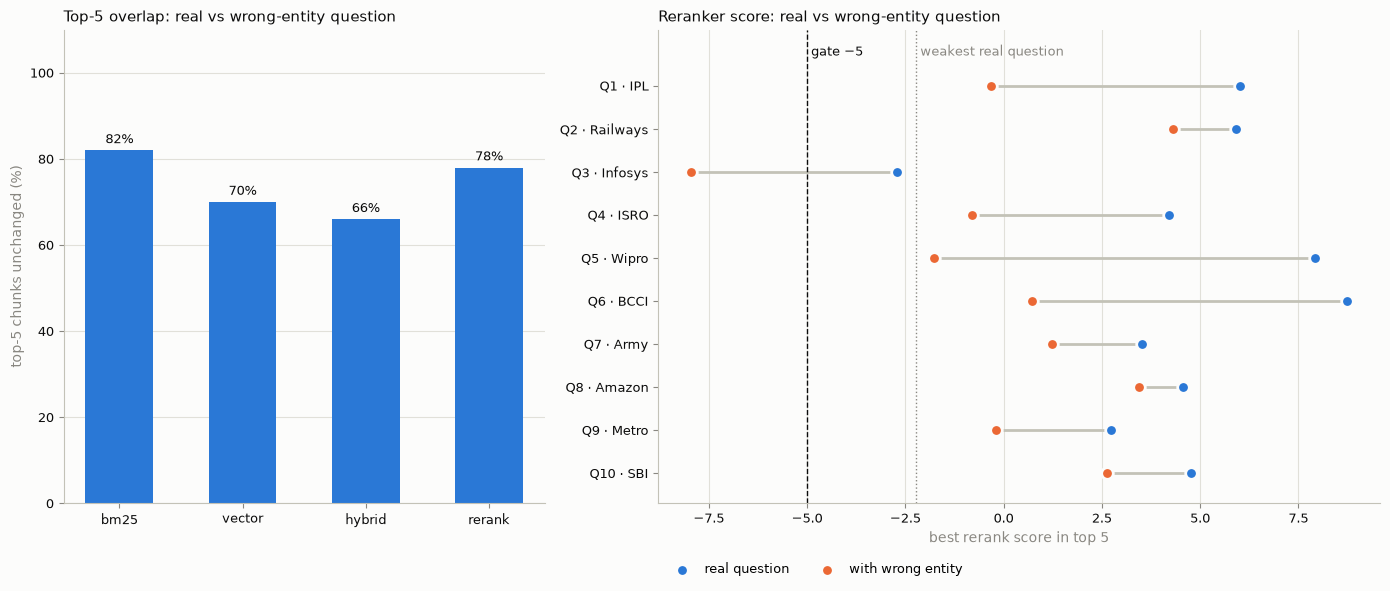

In [39]:
# 08.16  plot: does search notice the wrong entity?
import matplotlib.pyplot as plt

BLUE, ORANGE = "#2a78d6", "#eb6834"                      # real question / wrong-entity question
SURFACE, INK, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
WEAKEST_REAL = -2.22                                     # lowest best-rerank score of a real question (08.10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1, 1.5]})
fig.patch.set_facecolor(SURFACE)
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelcolor=INK, labelsize=9)
    ax.set_axisbelow(True)

# left: how much of the top 5 stays the same per method
pct = summary["overlap"] * 100
bars = ax1.bar(pct.index, pct.values, color=BLUE, width=0.55)
ax1.bar_label(bars, labels=[f"{v:.0f}%" for v in pct.values], padding=3, color=INK, fontsize=9)
ax1.set_ylim(0, 110)
ax1.yaxis.grid(True, color=GRID, linewidth=0.8)
ax1.set_ylabel("top-5 chunks unchanged (%)", color=MUTED)
ax1.set_title("Top-5 overlap: real vs wrong-entity question", loc="left", color=INK, fontsize=11)

# right: reranker best score per question, real (blue) -> wrong entity (orange)
ys = list(range(len(rr)))[::-1]
for y, real, wrong in zip(ys, rr.real_best, rr.wrong_best):
    ax2.plot([real, wrong], [y, y], color=AXIS, linewidth=2, zorder=1)
ax2.scatter(rr.real_best, ys, s=70, color=BLUE, edgecolors=SURFACE, linewidths=2, zorder=3, label="real question")
ax2.scatter(rr.wrong_best, ys, s=70, color=ORANGE, edgecolors=SURFACE, linewidths=2, zorder=3, label="with wrong entity")
ax2.axvline(THRESHOLD, color=INK, linestyle="--", linewidth=1)
ax2.axvline(WEAKEST_REAL, color=MUTED, linestyle=":", linewidth=1)
ax2.text(THRESHOLD, len(rr) - 0.3, " gate −5", color=INK, fontsize=9)
ax2.text(WEAKEST_REAL, len(rr) - 0.3, " weakest real question", color=MUTED, fontsize=9)
ax2.set_yticks(ys)
ax2.set_yticklabels([f"{q} · {e}" for q, e in zip(rr.q, rr.entity)])
ax2.set_ylim(-0.7, len(rr) + 0.3)
ax2.xaxis.grid(True, color=GRID, linewidth=0.8)
ax2.set_xlabel("best rerank score in top 5", color=MUTED)
ax2.set_title("Reranker score: real vs wrong-entity question", loc="left", color=INK, fontsize=11)
ax2.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, -0.1), ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

In [40]:
# 08.17  three-zone gate (CRAG idea) + evidence check (RINSE/SG-RAG idea) — retrieval only, no LLM
import re

LOWER, UPPER = -5.0, 0.0     # best rerank < LOWER: incorrect | LOWER..UPPER: ambiguous | >= UPPER: correct

def norm(text):
    """Lower-case and turn every kind of dash into '-' so '2024–25' matches '2024-25'."""
    return re.sub(r"[\u2010-\u2015\u2212]", "-", text.lower())

PDF_NUMBERS = {n for c in R.chunks for n in re.findall(r"\d+(?:-\d+)?", norm(c["text"]))}

def strong_parts(question):
    """The parts a sufficient answer must cover: names/acronyms (ALL CAPS, or capitalised and not
    the first word) and numbers/years. Ordinary words are left out because users paraphrase them."""
    words = re.findall(r"[A-Za-z][A-Za-z0-9]*", question)
    names = [w for i, w in enumerate(words) if (w.isupper() and len(w) > 1) or (i > 0 and w[0].isupper())]
    return names + re.findall(r"\d+(?:-\d+)?", norm(question))

def evidence_check(question, k=5):
    fixed, changes = SP.fix(question)
    hits = R.search(fixed, k=k)
    best = max(h["score"] for h in hits)
    evidence_words = set(re.findall(r"[a-z0-9]+(?:-\d+)?", norm(" ".join(h["path"] + " " + h["text"] for h in hits))))
    not_in_pdf, not_in_top5 = [], []
    for part in strong_parts(fixed):
        low = norm(part)
        in_pdf = low in PDF_NUMBERS if low[0].isdigit() else low in SP.vocab
        if not in_pdf:
            not_in_pdf.append(part)
        elif low not in evidence_words:
            not_in_top5.append(part)
    zone = "incorrect" if best < LOWER else "ambiguous" if best < UPPER else "correct"
    action = ("not_found" if zone == "incorrect" else "out_of_scope" if not_in_pdf
              else "missing_in_evidence" if not_in_top5 else "answer")
    return {"best": round(best, 2), "zone": zone, "action": action,
            "not_in_pdf": ", ".join(not_in_pdf), "not_in_top5": ", ".join(not_in_top5)}

GROUPS = [("real (scored)",      checked_df["question"].dropna().tolist(),  "answer"),
          ("real (rejected)",    rejected_df["question"].dropna().tolist(), "answer"),
          ("off-topic easy",     OFF_EASY,                                  "flag"),
          ("off-topic near",     OFF_NEAR,                                  "flag"),
          ("entity pair: real",  [pair[0] for pair in PAIRS],               "answer"),
          ("entity pair: wrong", [pair[1] for pair in PAIRS],               "flag")]

ev_df = pd.DataFrame([{"group": group, "question": q, "expected": expected, **evidence_check(q)}
                      for group, questions, expected in GROUPS for q in questions])
ev_df["ok"] = (ev_df["action"] == "answer") == (ev_df["expected"] == "answer")

order = [group[0] for group in GROUPS]
counts = ev_df.pivot_table(index="group", columns="action", values="question", aggfunc="count", fill_value=0)
counts["ok %"] = ev_df.groupby("group")["ok"].mean().mul(100).round(0)
print(counts.reindex(order).to_string())

wrong = ev_df[~ev_df["ok"]].sort_values(["group", "best"])
print(f"\nwrong decisions: {len(wrong)}")
print(wrong[["group", "best", "zone", "action", "not_in_pdf", "not_in_top5", "question"]].to_string(index=False))
ev_df.to_csv("../data/eval/evidence_check.csv", index=False)

action              answer  missing_in_evidence  not_found  out_of_scope   ok %
group                                                                          
real (scored)          176                    6          0             3   95.0
real (rejected)         15                    0          0             0  100.0
off-topic easy           0                    0         10             0  100.0
off-topic near           0                    0          9             2  100.0
entity pair: real       10                    0          0             0  100.0
entity pair: wrong       0                    1          1             8  100.0

wrong decisions: 9
        group  best      zone              action not_in_pdf not_in_top5                                                                                                        question
real (scored) -1.38 ambiguous missing_in_evidence                   What We received only one application for an important head-of-division post. What does

In [41]:
# 08.18  where should UPPER sit? % of each group that falls in the ambiguous zone (LOWER <= best < UPPER)
sweep = pd.DataFrame({upper: ev_df.assign(ambiguous=ev_df["best"].between(LOWER, upper, inclusive="left"))
                                   .groupby("group")["ambiguous"].mean().mul(100).round(0)
                      for upper in [-3, -2, -1, 0, 1, 2, 3]}).reindex(order)
print("% of each group in the ambiguous zone, for different UPPER values:")
print(sweep.to_string())

% of each group in the ambiguous zone, for different UPPER values:
                     -3    -2    -1     0     1     2     3
group                                                      
real (scored)       0.0   1.0   2.0   3.0   6.0  11.0  19.0
real (rejected)     0.0   0.0   7.0   7.0  13.0  13.0  20.0
off-topic easy      0.0   0.0   0.0   0.0   0.0   0.0   0.0
off-topic near      9.0   9.0   9.0  18.0  18.0  18.0  18.0
entity pair: real   0.0  10.0  10.0  10.0  10.0  10.0  20.0
entity pair: wrong  0.0   0.0  10.0  40.0  50.0  60.0  70.0


In [42]:
# 08.19  50 negative questions: none of them can be answered from the guideline
#        30 near-topic (real NHM topic + wrong entity/year, like IPL) | 12 off-topic health/HR | 8 irrelevant
NEGATIVES = [
    # --- near-topic: false premise (marker = the out-of-scope word that must NOT be in the PDF) ---
    ("near: false premise", "Who should be on the interview panel for IPL team recruitment?", "IPL"),
    ("near: false premise", "What skill test should a BCCI umpire candidate take?", "BCCI"),
    ("near: false premise", "How many members should an Infosys recruitment committee have?", "Infosys"),
    ("near: false premise", "Can a Wipro software engineer take maternity leave under this policy?", "Wipro"),
    ("near: false premise", "When will a leaving ISRO scientist get the relieving letter?", "ISRO"),
    ("near: false premise", "What is the process for claiming hotel stay expenses for Railways staff?", "Railways"),
    ("near: false premise", "How should DRDO conduct the written test for scientists?", "DRDO"),
    ("near: false premise", "What is the probation period for contractual staff in the Army?", "Army"),
    ("near: false premise", "Should Amazon review the JD and ToR before advertising a warehouse post?", "Amazon"),
    ("near: false premise", "How often should Flipkart review its vacancies and HR requirements?", "Flipkart"),
    ("near: false premise", "What is the performance appraisal format for Swiggy delivery partners?", "Swiggy"),
    ("near: false premise", "How are the contracts of Zomato employees renewed?", "Zomato"),
    ("near: false premise", "What is the difficult area allowance for SBI bank managers?", "SBI"),
    ("near: false premise", "Does LIC give a loyalty bonus to its agents?", "LIC"),
    ("near: false premise", "How should IndiGo pilots apply for leave?", "IndiGo"),
    ("near: false premise", "What is the transfer and posting policy for DMRC staff?", "DMRC"),
    ("near: false premise", "How is the entry level salary decided for a Google consultant?", "Google"),
    ("near: false premise", "What grievance redressal process should Microsoft employees follow?", "Microsoft"),
    ("near: false premise", "What welfare fund is available for Reliance retail staff?", "Reliance"),
    ("near: false premise", "How should Netflix conduct interviews for content writers?", "Netflix"),
    ("near: false premise", "Who should sit on the selection committee for FIFA referees?", "FIFA"),
    ("near: false premise", "What training should Olympics coaches receive before joining?", "Olympics"),
    ("near: false premise", "How does NASA rationalize its human resources?", "NASA"),
    ("near: false premise", "Can an Apple store employee get six months of maternity leave?", "Apple"),
    ("near: false premise", "How are Uber drivers given performance-based incentives?", "Uber"),
    ("near: false premise", "Which HR information system is used by Paytm?", "Paytm"),
    ("near: false premise", "Does TCS conduct annual health check-ups for employees over 40?", "TCS"),
    ("near: false premise", "How should a Bollywood film crew be recruited on contract?", "Bollywood"),
    ("near: false premise", "What is the NHM budget for the year 2031-32?", "2031-32"),
    ("near: false premise", "How many staff nurses were recruited under NHM in 2029?", "2029"),
    # --- off-topic: health / HR sounding, but not covered by this guideline ---
    ("off-topic", "What is the treatment for dengue fever?", ""),
    ("off-topic", "Which vaccines are given to a newborn baby?", ""),
    ("off-topic", "What is the normal blood pressure range for adults?", ""),
    ("off-topic", "What is the dose of paracetamol for a 5-year-old child?", ""),
    ("off-topic", "How do I register a private clinic in Delhi?", ""),
    ("off-topic", "What is the NEET cutoff for MBBS admission?", ""),
    ("off-topic", "How many beds does AIIMS Delhi have?", ""),
    ("off-topic", "What is the EPF contribution rate for private sector employees?", ""),
    ("off-topic", "How is income tax calculated on a government salary?", ""),
    ("off-topic", "What are the symptoms of tuberculosis?", ""),
    ("off-topic", "How do I apply for an Ayushman Bharat card?", ""),
    ("off-topic", "What is the minimum wage for nurses in private hospitals in Mumbai?", ""),
    # --- totally irrelevant ---
    ("irrelevant", "Who won the cricket world cup in 2011?", ""),
    ("irrelevant", "How do I make paneer butter masala?", ""),
    ("irrelevant", "What is the capital of Australia?", ""),
    ("irrelevant", "Write a Python function to sort a list.", ""),
    ("irrelevant", "What will the weather be in Delhi tomorrow?", ""),
    ("irrelevant", "Who directed the movie Sholay?", ""),
    ("irrelevant", "What is the share price of Tata Motors today?", ""),
    ("irrelevant", "Tell me a joke about cats.", ""),
]
neg_df = pd.DataFrame(NEGATIVES, columns=["type", "question", "marker"])

# fairness check: if a marker IS in the PDF, that question is not really out of scope -> replace it
in_pdf = lambda word: norm(word) in PDF_NUMBERS if word[0].isdigit() else norm(word) in SP.vocab
neg_df["marker_in_pdf"] = [bool(m) and in_pdf(m) for m in neg_df["marker"]]
print("markers found in the PDF (replace these questions):", neg_df[neg_df["marker_in_pdf"]]["marker"].tolist())

neg_df = neg_df.join(pd.DataFrame([evidence_check(q) for q in neg_df["question"]]))
neg_df["gate_only"] = neg_df["zone"] == "incorrect"          # what the old system (gate -5) catches
neg_df["gate_plus_check"] = neg_df["action"] != "answer"     # gate + evidence check

types = ["near: false premise", "off-topic", "irrelevant"]
summary = neg_df.pivot_table(index="type", columns="action", values="question", aggfunc="count", fill_value=0)
summary["gate only %"] = neg_df.groupby("type")["gate_only"].mean().mul(100).round(0)
summary["gate + check %"] = neg_df.groupby("type")["gate_plus_check"].mean().mul(100).round(0)
print("\ncaught = NOT answered (higher is better):")
print(summary.reindex(types).to_string())

real = ev_df[ev_df["expected"] == "answer"]
print(f"\nfalse alarms on real questions (lower is better): {(real['action'] != 'answer').mean():.1%} of {len(real)}")

missed = neg_df[~neg_df["gate_plus_check"]].sort_values("best", ascending=False)
print(f"\nmissed (would reach the LLM as a normal question): {len(missed)}")
print(missed[["type", "best", "zone", "not_in_top5", "question"]].to_string(index=False))
neg_df.to_csv("../data/eval/negatives_50.csv", index=False)

markers found in the PDF (replace these questions): ['Railways', 'Google', 'Microsoft']

caught = NOT answered (higher is better):
action               answer  missing_in_evidence  not_found  out_of_scope  gate only %  gate + check %
type                                                                                                  
near: false premise       0                    3          8            19         27.0           100.0
off-topic                 3                    0          9             0         75.0            75.0
irrelevant                0                    0          8             0        100.0           100.0

false alarms on real questions (lower is better): 4.3% of 210

missed (would reach the LLM as a normal question): 3
     type  best      zone not_in_top5                                                        question
off-topic -0.58 ambiguous             What is the EPF contribution rate for private sector employees?
off-topic -3.60 ambiguous        

In [43]:
# 08.20  Evidence evaluator: label every retrieval S / P / I / M, then compare with gold labels
#   S = sufficient (answer is in the top 5)          -> refine + answer
#   P = partial    (right topic, part/answer missing) -> re-retrieve
#   I = invalid    (nothing relevant in the guideline) -> reject
#   M = misleading (looks relevant, but the question is about something outside the guideline) -> reject / scoped answer
import re

LOWER, UPPER, COV_MIN = -5.0, 0.0, 0.6     # first guesses -> tune after reading the confusion matrix
IDF = R.bm25.idf

def flat(text):
    """Words only, lower case: for phrase matching that ignores punctuation and line breaks."""
    return " ".join(re.findall(r"[a-z0-9]+", norm(str(text))))

def signals(question, k=5):
    """Everything the evaluator looks at, computed once per question."""
    fixed, changes = SP.fix(question)
    hits = R.search(fixed, k=k)
    evidence = " ".join(h["path"] + " " + h["text"] for h in hits)
    evidence_words = set(re.findall(r"[a-z0-9]+(?:-\d+)?", norm(evidence)))
    q_tokens = set(R.tokenize(fixed))
    total_idf = sum(IDF.get(t, 0) for t in q_tokens)
    in_corpus = lambda part: norm(part) in PDF_NUMBERS if part[0].isdigit() else norm(part) in SP.vocab
    parts = strong_parts(fixed)
    return {"best": round(max(h["score"] for h in hits), 2),
            "coverage": round(sum(IDF.get(t, 0) for t in q_tokens & set(R.tokenize(evidence))) / total_idf, 2) if total_idf else 0.0,
            "out_of_corpus": [p for p in parts if not in_corpus(p)],
            "missing": [p for p in parts if in_corpus(p) and norm(p) not in evidence_words],
            "pages": {p for h in hits for p in h["pdf_pages"]},
            "evidence_flat": flat(evidence)}

def predict(sig):
    if sig["best"] < LOWER:
        return "I"
    if sig["out_of_corpus"]:
        return "M"
    if sig["missing"] or sig["coverage"] < COV_MIN or sig["best"] < UPPER:
        return "P"
    return "S"

def gold_for_real(row, sig):
    """Gold label from the answer key: right page AND (no phrase or phrase found) -> S, otherwise P."""
    targets = {int(p) for p in re.findall(r"\d+", str(row["pdf_page"]))}
    if not targets & {int(p) for p in sig["pages"]}:
        return "P"
    phrase = row.get("phrase")
    return "S" if not isinstance(phrase, str) or not phrase.strip() or flat(phrase) in sig["evidence_flat"] else "P"

def record(source, question, gold, sig):
    return {"source": source, "question": question, "gold": gold, "pred": predict(sig),
            "best": sig["best"], "coverage": sig["coverage"],
            "out_of_corpus": ", ".join(sig["out_of_corpus"]), "missing": ", ".join(sig["missing"])}

negatives = pd.read_csv("../data/eval/negatives_50.csv")
negatives = negatives[~negatives["marker_in_pdf"]]                       # drop Railways / Google / Microsoft

records  = [record("real (scored)", row["question"], gold_for_real(row, sig), sig)
            for row in checked_df.to_dict("records") for sig in [signals(row["question"])]]
records += [record("real (rejected)", q, "S/P", signals(q)) for q in rejected_df["question"].dropna()]
records += [record(row["type"], row["question"], "M" if row["type"].startswith("near") else "I", signals(row["question"]))
            for row in negatives.to_dict("records")]
lab_df = pd.DataFrame(records)

print("confusion matrix (rows = gold, columns = evaluator):")
print(pd.crosstab(lab_df["gold"], lab_df["pred"], margins=True).to_string())

answerable = lab_df["gold"].isin(["S", "P", "S/P"])
wrongly_rejected = lab_df[answerable & lab_df["pred"].isin(["I", "M"])]
wrongly_answered = lab_df[~answerable & (lab_df["pred"] == "S")]
exact = lab_df[lab_df["gold"] != "S/P"]
print(f"\nexact label accuracy (S/P/I/M):  {(exact['gold'] == exact['pred']).mean():.1%} of {len(exact)}")
print(f"wrongly rejected (real -> I/M):  {len(wrongly_rejected)} of {answerable.sum()}")
print(f"wrongly answered (I/M -> S):     {len(wrongly_answered)} of {(~answerable).sum()}")

columns = ["source", "gold", "pred", "best", "coverage", "out_of_corpus", "missing", "question"]
print("\nwrongly rejected:");  print(wrongly_rejected[columns].to_string(index=False))
print("\nwrongly answered:");  print(wrongly_answered[columns].to_string(index=False))
lab_df.to_csv("../data/eval/evidence_labels.csv", index=False)

confusion matrix (rows = gold, columns = evaluator):
pred   I   M   P    S  All
gold                      
I     17   0   3    0   20
M      8  19   0    0   27
P      0   0   1    1    2
S      0   3  21  159  183
S/P    0   0   4   11   15
All   25  22  29  171  247

exact label accuracy (S/P/I/M):  84.5% of 232
wrongly rejected (real -> I/M):  3 of 200
wrongly answered (I/M -> S):     0 of 47

wrongly rejected:
       source gold pred  best  coverage out_of_corpus missing                                                                                   question
real (scored)    S    M  0.86      0.75       Supreme   Court Does the Supreme Court's equal pay for equal work judgment raise NHM contractual salaries?
real (scored)    S    M  6.21      0.77           P4P       4                         For what term are contractual staff engaged in Odisha's P4P model?
real (scored)    S    M  5.48      0.80           P4P       4                        What welfare measures exist for NHM st

In [44]:
# 08.21  Evidence evaluator v2: the 5 fixes, then the same comparison as 08.20
#   fix 1: alphanumeric words (P4P) are part of the vocabulary; numbers only count when they stand alone
#   fix 2: the first word of EVERY sentence is not a name ("... drive. What should ...")
#   fix 3: words are compared by stem (Operators = operator, Centres = centre)
#   fix 4: HARD names (acronyms / not English: IPL, Infosys) -> M;  SOFT names (English words: Army, Supreme) -> P
#   fix 5: coverage no longer decides the label (still shown for reading)
import re

COV_MIN = 0.0                                           # 0 = coverage switched off as a trigger
NUMBER = r"(?<![a-z0-9])\d+(?:-\d+)?(?![a-z0-9])"       # 2024-25, 40 — but not the 4 inside P4P

def stems(text):
    return set(R.tokenize(norm(text)))

CORPUS_STEMS = {s for c in R.chunks for s in stems(c["embed_text"])}

def strong_parts_v2(question):
    """Returns (hard, soft, numbers). Sentence-first words are skipped unless they are ALL CAPS."""
    hard, soft = [], []
    for sentence in re.split(r"(?<=[.?!])\s+", question.strip()):
        for i, word in enumerate(re.findall(r"[A-Za-z][A-Za-z0-9]*", sentence)):
            acronym = word.isupper() and len(word) > 1
            if not acronym and (i == 0 or not word[0].isupper()):
                continue
            is_english = bool(SP.english.known([word.lower()]))
            (hard if acronym or not is_english else soft).append(word)
    return hard, soft, re.findall(NUMBER, norm(question))

def signals_v2(question, k=5):
    fixed, changes = SP.fix(question)
    hits = R.search(fixed, k=k)
    evidence = " ".join(h["path"] + " " + h["text"] for h in hits)
    evidence_stems, evidence_numbers = stems(evidence), set(re.findall(NUMBER, norm(evidence)))
    q_stems = stems(fixed)
    total_idf = sum(IDF.get(t, 0) for t in q_stems)
    hard, soft, numbers = strong_parts_v2(fixed)

    def word_status(word):
        word_stems = stems(word)
        if not word_stems:                                   # a stop word, e.g. "What"
            return "ok"
        if not word_stems <= CORPUS_STEMS:
            return "out"
        return "ok" if word_stems <= evidence_stems else "missing"

    status = {w: word_status(w) for w in hard + soft}
    status.update({n: "ok" if n in evidence_numbers else ("missing" if n in PDF_NUMBERS else "out") for n in numbers})
    return {"best": round(max(h["score"] for h in hits), 2),
            "coverage": round(sum(IDF.get(t, 0) for t in q_stems & evidence_stems) / total_idf, 2) if total_idf else 0.0,
            "hard_out": [p for p in hard + numbers if status[p] == "out"],
            "soft_out": [p for p in soft if status[p] == "out"],
            "missing": [p for p in status if status[p] == "missing"],
            "pages": {p for h in hits for p in h["pdf_pages"]},
            "evidence_flat": flat(evidence)}

def predict_v2(sig):
    if sig["best"] < LOWER:
        return "I"
    if sig["hard_out"]:
        return "M"
    if sig["soft_out"] or sig["missing"] or sig["best"] < UPPER or sig["coverage"] < COV_MIN:
        return "P"
    return "S"

def record_v2(source, question, gold, sig):
    return {"source": source, "question": question, "gold": gold, "pred": predict_v2(sig),
            "best": sig["best"], "coverage": sig["coverage"], "hard_out": ", ".join(sig["hard_out"]),
            "soft_out": ", ".join(sig["soft_out"]), "missing": ", ".join(sig["missing"])}

negatives = pd.read_csv("../data/eval/negatives_50.csv")
negatives = negatives[~negatives["marker_in_pdf"]]
records  = [record_v2("real (scored)", row["question"], gold_for_real(row, sig), sig)
            for row in checked_df.to_dict("records") for sig in [signals_v2(row["question"])]]
records += [record_v2("real (rejected)", q, "S/P", signals_v2(q)) for q in rejected_df["question"].dropna()]
records += [record_v2(row["type"], row["question"], "M" if row["type"].startswith("near") else "I", signals_v2(row["question"]))
            for row in negatives.to_dict("records")]
lab2 = pd.DataFrame(records)

print("confusion matrix v2 (rows = gold, columns = evaluator):")
print(pd.crosstab(lab2["gold"], lab2["pred"], margins=True).to_string())

old = pd.read_csv("../data/eval/evidence_labels.csv")[["source", "question", "pred"]].rename(columns={"pred": "pred_v1"})
lab2 = lab2.merge(old, on=["source", "question"], how="left")

def scorecard(pred_column):
    answerable = lab2["gold"].isin(["S", "P", "S/P"])
    exact = lab2[lab2["gold"] != "S/P"]
    return {"exact accuracy %": round((exact["gold"] == exact[pred_column]).mean() * 100, 1),
            "wrongly rejected (real -> I/M)": int((answerable & lab2[pred_column].isin(["I", "M"])).sum()),
            "wrongly answered (I/M -> S)": int((~answerable & (lab2[pred_column] == "S")).sum()),
            "real S labelled P": int(((lab2["gold"] == "S") & (lab2[pred_column] == "P")).sum())}

print("\nv1 vs v2:")
print(pd.DataFrame({"v1": scorecard("pred_v1"), "v2": scorecard("pred")}).to_string())

changed = lab2[lab2["pred"] != lab2["pred_v1"]]
print(f"\nquestions whose label changed: {len(changed)}")
print(changed[["source", "gold", "pred_v1", "pred", "best", "hard_out", "soft_out", "missing", "question"]].to_string(index=False))

still_wrong = lab2[(lab2["gold"] == "S") & (lab2["pred"] != "S")]
print(f"\nreal S still not labelled S: {len(still_wrong)}")
print(still_wrong[["pred", "best", "coverage", "hard_out", "soft_out", "missing", "question"]].to_string(index=False))
lab2.to_csv("../data/eval/evidence_labels_v2.csv", index=False)

confusion matrix v2 (rows = gold, columns = evaluator):
pred   I   M   P    S  All
gold                      
I     17   0   3    0   20
M      8  16   3    0   27
P      0   0   1    1    2
S      0   0   6  177  183
S/P    0   0   1   14   15
All   25  16  14  192  247

v1 vs v2:
                                  v1    v2
exact accuracy %                84.5  90.9
wrongly rejected (real -> I/M)   3.0   0.0
wrongly answered (I/M -> S)      0.0   0.0
real S labelled P               21.0   6.0

questions whose label changed: 25
             source gold pred_v1 pred  best hard_out  soft_out missing                                                                                                        question
      real (scored)    S       P    S  3.21                                             We are planning a new NHM recruitment drive. What should HR confirm before the process begins?
      real (scored)    S       P    S  5.43                            Can someone from the programme

In [45]:
# 08.22  The three action boxes: REFINE (S), RE-RETRIEVE (P), REJECT / SCOPED (I / M)
import re, time
from src.retriever import STOP
import src.answer as answer_mod

NOT_FOUND = answer_mod.NOT_FOUND
KEEP_STRIPS = 2        # REFINE: best sentences kept per chunk (+ one neighbour on each side)
POOL = 10              # RE-RETRIEVE: candidates per query variant

def signals_from_hits(fixed, hits):
    """Same signals as signals_v2, but for hits we already have (needed after re-retrieval)."""
    evidence = " ".join(h["path"] + " " + h["text"] for h in hits)
    evidence_stems, evidence_numbers = stems(evidence), set(re.findall(NUMBER, norm(evidence)))
    hard, soft, numbers = strong_parts_v2(fixed)

    def word_status(word):
        word_stems = stems(word)
        if not word_stems:
            return "ok"
        if not word_stems <= CORPUS_STEMS:
            return "out"
        return "ok" if word_stems <= evidence_stems else "missing"

    status = {w: word_status(w) for w in hard + soft}
    status.update({n: "ok" if n in evidence_numbers else ("missing" if n in PDF_NUMBERS else "out") for n in numbers})
    return {"best": round(max(h["score"] for h in hits), 2), "coverage": 1.0,
            "hard_out": [p for p in hard + numbers if status[p] == "out"],
            "soft_out": [p for p in soft if status[p] == "out"],
            "missing": [p for p in status if status[p] == "missing"]}

def re_retrieve(fixed, sig, k=5):
    """CRAG idea, our version: widen the search INSIDE the guideline with query variants,
    then let the reranker judge every candidate against the ORIGINAL question."""
    keywords = " ".join(w for w in re.findall(r"[A-Za-z0-9][A-Za-z0-9-]*", fixed) if w.lower() not in STOP)
    queries = [fixed, keywords] + ([" ".join(sig["missing"]) + " " + keywords] if sig["missing"] else [])
    pool = list({h["chunk_id"]: h for q in queries for h in R.search(q, k=POOL)}.values())
    scores = R.reranker.rerank(fixed, [R.chunks[R.row_of[h["chunk_id"]]]["embed_text"] for h in pool])
    for hit, score in zip(pool, scores):
        hit["score"] = float(score)
    return sorted(pool, key=lambda h: -h["score"])[:k]

def refine(hits, question):
    """CRAG idea, our version: keep the best sentences of each chunk (+ neighbours), in their original order.
    Tables are kept whole, because cutting rows breaks table reading."""
    for hit in hits:
        sentences = [s.strip() for s in re.split(r"(?<=[.;?])\s+|\n+", hit["text"]) if s.strip()]
        if hit["doc_type"] == "table" or len(sentences) <= 2 * KEEP_STRIPS + 1:
            continue
        scores = list(R.reranker.rerank(question, sentences))
        top = sorted(range(len(sentences)), key=lambda i: -scores[i])[:KEEP_STRIPS]
        chosen = sorted({j for i in top for j in (i - 1, i, i + 1) if 0 <= j < len(sentences)})
        parts = [("… " if n and j != chosen[n - 1] + 1 else "") + sentences[j] for n, j in enumerate(chosen)]
        hit["text"] = " ".join(parts)
    return hits

def notes_for(sig):
    """What the LLM must be told when the evidence is still only partial."""
    notes = []
    if sig["soft_out"]:
        notes.append(f"The sources do not mention {', '.join(sig['soft_out'])}. Say that the guideline does not cover it; "
                     f"answer only for NHM if the sources clearly cover that.")
    if sig["missing"]:
        notes.append(f"The sources may not contain: {', '.join(sig['missing'])}.")
    if sig["best"] < UPPER:
        notes.append(f"The evidence is weak. If the sources do not clearly answer the question, reply exactly: {NOT_FOUND}")
    return notes

def corrective_answer(question):
    t0 = time.time()
    fixed, changes = SP.fix(question)
    hits = R.search(fixed, k=5)
    sig = signals_from_hits(fixed, hits)
    first = final = predict_v2(sig)
    if first == "P":                                             # RE-RETRIEVE, then judge again
        hits = re_retrieve(fixed, sig)
        sig = signals_from_hits(fixed, hits)
        final = predict_v2(sig)
    result = {"question": question, "first": first, "final": final}
    if final == "I":                                             # REJECT
        return {**result, "action": "reject", "answer": NOT_FOUND, "notes": "", "seconds": round(time.time() - t0, 1)}
    if final == "M":                                             # SCOPED REJECT (no LLM)
        terms = ", ".join(sig["hard_out"])
        answer = f"The guideline does not cover {terms}. It covers human resources under the National Health Mission (NHM) only."
        return {**result, "action": "scoped", "answer": answer, "notes": "", "seconds": round(time.time() - t0, 1)}
    notes = notes_for(sig) if final == "P" else []               # S -> plain answer, P -> answer with notes
    hits = refine(answer_mod.add_context(hits, R), fixed)         # neighbour expansion, then REFINE
    prompt = ("Important: " + " ".join(notes) + "\n\n" if notes else "") + answer_mod.build_prompt(fixed, hits)
    return {**result, "action": "answer_with_note" if notes else "answer", "answer": ans.generate(prompt),
            "notes": " | ".join(notes), "seconds": round(time.time() - t0, 1)}

In [46]:
# ===================== 09.0 Setup =====================
import sys, re, time
from pathlib import Path
from datetime import datetime
import pandas as pd


import importlib
import src.query as Q
import src.answer as A
from src.retriever import Retriever
from src.answer import Answerer

R = Retriever()            # only if R doesn't exist yet
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.retriever import Retriever
from src.answer import Answerer

EVAL_DIR = ROOT / "data" / "eval"
ANSWER_QUESTIONS = EVAL_DIR / "answer_questions.csv"
MODELS = ["llama3.2:3b", "phi4-mini"]
# MODELS = ["llama3.2:3b", "phi4-mini", "qwen3:4b"]
# # MODELS =["qwen3:4b"]

R = Retriever()                      # one retriever, shared by every model
print(f"{len(R.chunks)} chunks loaded")

466 chunks loaded


In [48]:
# 08.23  End-to-end test on a sample (~60 questions, ~20-30 min): what would the user actually see?
ans = answer_mod.Answerer("phi4-mini", retriever=R)

def pick(label, n=None):
    group = lab2[lab2["pred"] == label]
    return group if n is None else group.sample(min(n, len(group)), random_state=1)

sample = pd.concat([pick("P"), pick("M"), pick("I", 10), pick("S", 20)])
print(f"{len(sample)} questions; LLM calls only for S and P")

rows = []
for row in sample.to_dict("records"):
    out = corrective_answer(row["question"])
    outcome = ("not_found" if out["answer"].startswith(NOT_FOUND.rstrip(".")) else
               "scoped" if out["action"] == "scoped" or re.search(r"does not (cover|mention)|not covered", out["answer"], re.I)
               else "answered")
    rows.append({"source": row["source"], "gold": row["gold"], **out, "outcome": outcome})
    print(f"{len(rows):3} {out['first']}->{out['final']} {outcome:9} {out['seconds']:5}s  {row['question'][:70]}")
e2e = pd.DataFrame(rows)
e2e["real"] = e2e["gold"].isin(["S", "P", "S/P"])

print("\nwhat the user sees (rows = real question or not):")
print(pd.crosstab(e2e["real"].map({True: "real", False: "negative"}), e2e["outcome"], margins=True).to_string())
print("\nP questions: label before -> after re-retrieval:")
print(pd.crosstab(e2e[e2e["first"] == "P"]["source"], e2e[e2e["first"] == "P"]["final"]).to_string())
print(f"\naverage seconds: answered {e2e[e2e['outcome'] == 'answered']['seconds'].mean():.1f} | "
      f"rejected {e2e[e2e['outcome'] != 'answered']['seconds'].mean():.1f}")

bad_neg = e2e[~e2e["real"] & (e2e["outcome"] == "answered")]
bad_real = e2e[e2e["real"] & (e2e["outcome"] != "answered")]
print(f"\nNEGATIVES that got an answer: {len(bad_neg)}")
for r in bad_neg.to_dict("records"):
    print(f"- [{r['first']}->{r['final']}] {r['question']}\n  notes: {r['notes']}\n  answer: {r['answer'][:300]}\n")
print(f"REAL questions NOT answered: {len(bad_real)}")
for r in bad_real.to_dict("records"):
    print(f"- [{r['first']}->{r['final']}] {r['question']}\n  notes: {r['notes']}\n  answer: {r['answer'][:200]}\n")
e2e.to_csv("../data/eval/corrective_e2e.csv", index=False)

60 questions; LLM calls only for S and P


ConnectionError: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/chat (Caused by NewConnectionError("HTTPConnection(host='localhost', port=11434): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))

In [ ]:
# # 08.24  Correctness review helper: which answers probably miss the expected content?
# keys = checked_df.reindex(columns=["question", "pdf_page", "phrase"]).drop_duplicates("question")
# review = e2e[e2e["real"] & (e2e["outcome"] == "answered")].merge(keys, on="question", how="left")

# def phrase_overlap(phrase, answer):
#     """Share of the answer-key phrase's words (stemmed) found in the LLM answer. NaN = no phrase to compare."""
#     if not isinstance(phrase, str) or not phrase.strip():
#         return float("nan")
#     key = stems(phrase)
#     return round(len(key & stems(answer)) / len(key), 2) if key else float("nan")

# review["overlap"] = [phrase_overlap(p, a) for p, a in zip(review["phrase"], review["answer"])]
# review["has_citation"] = review["answer"].str.contains(r"\[\d", regex=True)
# review["human_ok"] = ""                                          # fill in Excel: Y / N / partial
# review = review.sort_values("overlap", na_position="first")      # most doubtful first

# print(f"{len(review)} answered real questions | with citation: {review['has_citation'].mean():.0%} | "
#       f"median overlap: {review['overlap'].median():.2f}")
# for r in review.to_dict("records"):
#     print(f"\n[{r['overlap']}] [{r['first']}->{r['final']}] {r['question']}"
#           f"\n  key   : {r['phrase']}\n  answer: {r['answer'][:400]}")
# review[["question", "first", "final", "overlap", "has_citation", "phrase", "answer", "notes", "human_ok"]] \
#     .to_csv("../data/eval/answer_review.csv", index=False)

In [ ]:
# import zipfile
# from pathlib import Path
# ROOT = Path.cwd().parent                       # notebooks/ -> project root
# files = sorted((ROOT / "src").glob("*.py")) + [ROOT / p for p in [
#     "data/interim/chunks.jsonl", "data/eval/answer_questions.csv", "data/eval/negatives_50.csv"]]
# with zipfile.ZipFile(ROOT / "colab_bundle.zip", "w", zipfile.ZIP_DEFLATED) as z:
#     for f in files:
#         z.write(f, f.relative_to(ROOT).as_posix())
# print("zipped:", [f.relative_to(ROOT).as_posix() for f in files])
# # ``

# # Then: upload `colab_bundle.zip` to Google Drive → **Share → Anyone with the link → Viewer** → copy the link.
# # The **FILE_ID** is the part between `/d/` and `/view`. (The guideline is a public document; you can switch the link off again after testing.)

zipped: ['src/__init__.py', 'src/answer.py', 'src/paths.py', 'src/profile_pdf.py', 'src/query.py', 'src/retriever.py', 'src/test_extract.py', 'src/text_utils.py', 'data/interim/chunks.jsonl', 'data/eval/answer_questions.csv', 'data/eval/negatives_50.csv']


In [ ]:
# import zipfile
# from pathlib import Path
# ROOT = Path.cwd().parent                                   # notebooks/ -> project root
# files = (sorted((ROOT / "src").glob("*.py")) + [ROOT / "data/interim/chunks.jsonl"]
#          + sorted((ROOT / "data/eval/benchmark").glob("*.csv")))
# with zipfile.ZipFile(ROOT / "colab_bundle.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
#     for path in files:
#         bundle.write(path, path.relative_to(ROOT).as_posix())
# print(len(files), "files ->", ROOT / "colab_bundle1.zip")

19 files -> d:\SwasthyaSetu\colab_bundle1.zip
